# Анализ лояльности пользователей Яндекс Афиши

В этом проекте я провожу исследовательский анализ данных по пользователям Яндекс Афиши. **Бизнес-контекст проекта** задан маркетинговой командой: ей важно понять, какие пользователи с большей вероятностью возвращаются на платформу и оформляют повторные заказы. Это нужно для того, чтобы **быстрее выявлять перспективных клиентов**, точнее настраивать рекламные кампании, **оптимизировать маркетинговые бюджеты** и в итоге повышать удержание.

В основе исследования лежит **SQL-выгрузка заказов пользователей**. В данных есть сведения о самом заказе и его времени, устройстве покупки, выручке, количестве билетов, типе мероприятия, билетном операторе, регионе и городе, а также интервале между заказами. Это позволяет посмотреть на возврат пользователей сразу с нескольких сторон: через **характеристики первого заказа**, **структуру трат**, **состав корзины**, **временные признаки** и **агрегированный профиль пользователя**.

В рамках проекта я последовательно решаю несколько задач:
- проверяю качество выгрузки и подготавливаю данные к анализу;
- строю профиль пользователя с признаками, которые могут пригодиться маркетингу и будущей модели;
- исследую, какие сегменты и сценарии первого заказа чаще связаны с возвратом;
- анализирую связь повторных покупок со средней выручкой, количеством билетов и временными характеристиками;
- отдельно оцениваю, какие признаки сильнее связаны с числом заказов по результатам корреляционного анализа `phi_k`.

**Итоговая цель исследования** для меня здесь двойная: с одной стороны, аккуратно и последовательно разобрать поведение пользователей, а с другой — перевести результаты в понятные выводы и рекомендации, которые можно использовать в маркетинговой работе.


## Этапы выполнения проекта

### 1. Загрузка данных и их предобработка

---

**Задача 1.1:** Напишите SQL-запрос, выгружающий в датафрейм pandas необходимые данные.

Для выгрузки используйте запрос из предыдущего урока и библиотеку SQLAlchemy.

Выгрузка из базы данных SQL должна позволить собрать следующие данные:

- `user_id` — уникальный идентификатор пользователя, совершившего заказ;
- `device_type_canonical` — тип устройства, с которого был оформлен заказ (`mobile` — мобильные устройства, `desktop` — стационарные);
- `order_id` — уникальный идентификатор заказа;
- `order_dt` — дата создания заказа (используйте данные `created_dt_msk`);
- `order_ts` — дата и время создания заказа (используйте данные `created_ts_msk`);
- `currency_code` — валюта оплаты;
- `revenue` — выручка от заказа;
- `tickets_count` — количество купленных билетов;
- `days_since_prev` — количество дней от предыдущей покупки пользователя, для пользователей с одной покупкой — значение пропущено;
- `event_id` — уникальный идентификатор мероприятия;
- `service_name` — название билетного оператора;
- `event_type_main` — основной тип мероприятия (театральная постановка, концерт и так далее);
- `region_name` — название региона, в котором прошло мероприятие;
- `city_name` — название города, в котором прошло мероприятие.

---


---
### 1.1 Загрузка данных из PostgreSQL

Чтобы ноутбук запускался предсказуемо, зависимости я не устанавливаю изнутри через `!pip`. Если проект запускается впервые, достаточно один раз выполнить `pip install -r requirements.txt` в корне проекта и открыть ноутбук в ядре из `.venv`.

На этом шаге импортирую библиотеки, загружаю параметры окружения из `.env` и подготавливаю рабочие настройки для анализа.

Ниже также добавляю небольшой блок совместимости со старыми версиями `matplotlib`, чтобы подписи на графиках корректно работали и в более простом окружении.


In [1]:
import os
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.axes import Axes
import numpy as np
import pandas as pd
import phik
import seaborn as sns
from dotenv import load_dotenv
from IPython.display import display
from sqlalchemy import create_engine

load_dotenv(Path.cwd() / '.env')

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 20)

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

if not hasattr(Axes, 'bar_label'):
    def _bar_label(self, container, labels=None, label_type='edge', padding=0, **kwargs):
        bars = list(container)

        if labels is None:
            labels = []
            for bar in bars:
                horizontal = bar.get_width() >= bar.get_height()
                value = bar.get_width() if horizontal else bar.get_height()
                labels.append(f'{value:g}')

        for bar, label in zip(bars, labels):
            if label in (None, ''):
                continue

            x = bar.get_x()
            y = bar.get_y()
            width = bar.get_width()
            height = bar.get_height()
            horizontal = width >= height

            if horizontal:
                if label_type == 'center':
                    xy = (x + width / 2, y + height / 2)
                    xytext = (0, 0)
                    ha, va = 'center', 'center'
                else:
                    xy = (x + width, y + height / 2)
                    xytext = (padding, 0)
                    ha, va = 'left', 'center'
            else:
                if label_type == 'center':
                    xy = (x + width / 2, y + height / 2)
                    xytext = (0, 0)
                    ha, va = 'center', 'center'
                else:
                    xy = (x + width / 2, y + height)
                    xytext = (0, padding)
                    ha, va = 'center', 'bottom'

            self.annotate(
                str(label),
                xy=xy,
                xytext=xytext,
                textcoords='offset points',
                ha=ha,
                va=va,
                **kwargs
            )

        return bars

    Axes.bar_label = _bar_label


Готовлю параметры подключения и текст SQL-запроса. Параметры беру из `.env`, а сам запрос оформляю в стиле урока: с `set_config_precode` и явными `JOIN`.


In [2]:
required_env_vars = [
    'AFISHA_DB_USER',
    'AFISHA_DB_PASSWORD',
    'AFISHA_DB_HOST',
    'AFISHA_DB_PORT',
    'AFISHA_DB_NAME'
]

missing_env_vars = [var for var in required_env_vars if not os.getenv(var)]
if missing_env_vars:
    raise ValueError(
        'Не найдены обязательные переменные окружения: '
        + ', '.join(missing_env_vars)
        + '. Добавьте их в файл .env по образцу .env.example.'
    )

db_config = {
    'user': os.getenv('AFISHA_DB_USER'),
    'pwd': os.getenv('AFISHA_DB_PASSWORD'),
    'host': os.getenv('AFISHA_DB_HOST'),
    'port': int(os.getenv('AFISHA_DB_PORT')),
    'db': os.getenv('AFISHA_DB_NAME')
}

connection_string = 'postgresql://{}:{}@{}:{}/{}'.format(
    db_config['user'],
    db_config['pwd'],
    db_config['host'],
    db_config['port'],
    db_config['db']
)

query = '''
-- Настройка параметра synchronize_seqscans важна для проверки
WITH set_config_precode AS (
    SELECT set_config('synchronize_seqscans', 'off', true)
)
SELECT
    p.user_id,
    p.device_type_canonical,
    p.order_id,
    p.created_dt_msk::date AS order_dt,
    p.created_ts_msk AS order_ts,
    p.currency_code,
    p.revenue,
    p.tickets_count,
    (
        p.created_dt_msk::date
        - LAG(p.created_dt_msk::date) OVER (
            PARTITION BY p.user_id
            ORDER BY p.created_ts_msk, p.order_id
        )
    )::int AS days_since_prev,
    p.event_id,
    p.service_name,
    e.event_type_main,
    r.region_name,
    c.city_name
FROM afisha.purchases AS p
INNER JOIN afisha.events AS e
    ON p.event_id = e.event_id
INNER JOIN afisha.city AS c
    ON e.city_id = c.city_id
INNER JOIN afisha.regions AS r
    ON c.region_id = r.region_id
ORDER BY p.user_id, p.created_ts_msk, p.order_id
'''


Выполняю запрос и сохраняю результат в датафрейм `df`. Для самопроверки сразу вывожу размер выгрузки и первые 10 строк.


In [3]:
engine = create_engine(connection_string)
df = pd.read_sql_query(query, con=engine)
engine.dispose()

print(f'Выгрузка загружена: {df.shape[0]:,} строк и {df.shape[1]} столбцов'.replace(',', ' '))
df.head(10)


Выгрузка загружена: 292 034 строк и 14 столбцов


,user_id,device_type_canonical,order_id,order_dt,order_ts,currency_code,revenue,tickets_count,days_since_prev,event_id,service_name,event_type_main,region_name,city_name
0,0002849b70a3ce2,mobile,4359165,2024-08-20,2024-08-20 16:08:03,rub,1521.94,4,NaN,169230,Край билетов,театр,Каменевский регион,Глиногорск
1,0005ca5e93f2cf4,mobile,7965605,2024-07-23,2024-07-23 18:36:24,rub,289.45,2,NaN,237325,Мой билет,выставки,Каменевский регион,Глиногорск
2,0005ca5e93f2cf4,mobile,7292370,2024-10-06,2024-10-06 13:56:02,rub,1258.57,4,75.0,578454,За билетом!,другое,Каменевский регион,Глиногорск
3,000898990054619,mobile,1139875,2024-07-13,2024-07-13 19:40:48,rub,8.49,2,NaN,387271,Лови билет!,другое,Североярская область,Озёрск
4,000898990054619,mobile,972400,2024-10-04,2024-10-04 22:33:15,rub,1390.41,3,83.0,509453,Билеты без проблем,стендап,Озернинский край,Родниковецк
5,000898990054619,mobile,2613713,2024-10-23,2024-10-23 15:12:00,rub,902.74,3,19.0,500862,Облачко,концерты,Лугоградская область,Кристалевск
6,00096d1f542ab2b,desktop,6636941,2024-08-15,2024-08-15 16:48:48,rub,917.83,4,NaN,201953,Край билетов,театр,Каменевский регион,Глиногорск
7,000a55a418c128c,mobile,4657981,2024-09-29,2024-09-29 19:39:12,rub,47.78,1,NaN,265857,Лучшие билеты,театр,Поленовский край,Дальнозолотск
8,000a55a418c128c,mobile,4657952,2024-10-15,2024-10-15 10:29:04,rub,74.84,2,16.0,271579,Лучшие билеты,театр,Поленовский край,Дальнозолотск
9,000cf0659a9f40f,mobile,6818017,2024-06-20,2024-06-20 10:35:26,rub,1421.91,4,NaN,516728,Лови билет!,концерты,Широковская область,Радужнополье


---

**Задача 1.2:** Изучите общую информацию о выгруженных данных. Оцените корректность выгрузки и объём полученных данных.

Предположите, какие шаги необходимо сделать на стадии предобработки данных — например, скорректировать типы данных.

Зафиксируйте основную информацию о данных в кратком промежуточном выводе.

---

### 1.2 Первичная проверка структуры и качества выгрузки

На этом шаге я оцениваю объём данных, типы, пропуски и базовую корректность ключевых полей. Это помогает понять, какие действия действительно нужны на этапе предобработки и нет ли ошибок уже на входе.

In [4]:
print('Общая информация о датафрейме:')
df.info(show_counts=True)

overview = pd.Series({
    'rows': len(df),
    'columns': df.shape[1],
    'unique_users': df['user_id'].nunique(),
    'unique_orders': df['order_id'].nunique(),
    'date_min': df['order_dt'].min(),
    'date_max': df['order_dt'].max(),
    'duplicated_order_id': int(df['order_id'].duplicated().sum()),
    'missing_days_since_prev': int(df['days_since_prev'].isna().sum()),
    'non_positive_revenue': int((df['revenue'] <= 0).sum())
})

column_summary = (
    pd.DataFrame({
        'dtype': df.dtypes.astype(str),
        'non_null': df.notna().sum(),
        'null_count': df.isna().sum(),
        'null_share_pct': (df.isna().mean() * 100).round(2),
        'nunique': df.nunique()
    })
    .sort_values(['null_count', 'nunique'], ascending=[False, False])
)

print('\nКлючевые метрики выгрузки:')
print(overview.to_string())

print('\nСводка по столбцам:')
print(column_summary.to_string())

print('\nКатегории в device_type_canonical:', ', '.join(sorted(df['device_type_canonical'].unique())))
print('Категории в currency_code:', ', '.join(sorted(df['currency_code'].unique())))
print(f"Диапазон revenue: {df['revenue'].min():.2f} .. {df['revenue'].max():.2f}")
print(f"Диапазон tickets_count: {df['tickets_count'].min()} .. {df['tickets_count'].max()}")

Общая информация о датафрейме:
<class 'pandas.DataFrame'>
RangeIndex: 292034 entries, 0 to 292033
Data columns (total 14 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   user_id                292034 non-null  str           
 1   device_type_canonical  292034 non-null  str           
 2   order_id               292034 non-null  int64         
 3   order_dt               292034 non-null  object        
 4   order_ts               292034 non-null  datetime64[us]
 5   currency_code          292034 non-null  str           
 6   revenue                292034 non-null  float64       
 7   tickets_count          292034 non-null  int64         
 8   days_since_prev        270034 non-null  float64       
 9   event_id               292034 non-null  int64         
 10  service_name           292034 non-null  str           
 11  event_type_main        292034 non-null  str           
 12  region_name            2


Ключевые метрики выгрузки:
rows                           292034
columns                            14
unique_users                    22000
unique_orders                  292034
date_min                   2024-06-01
date_max                   2024-10-31
duplicated_order_id                 0
missing_days_since_prev         22000
non_positive_revenue             6153

Сводка по столбцам:
                                dtype  non_null  null_count  null_share_pct  nunique
days_since_prev               float64    270034       22000            7.53      149
order_id                        int64    292034           0            0.00   292034
order_ts               datetime64[us]    292034           0            0.00   282068
revenue                       float64    292034           0            0.00    42601
event_id                        int64    292034           0            0.00    22484
user_id                           str    292034           0            0.00    22000
city_name     

**Промежуточный вывод (шаг 1.2):**

- Выгрузка выглядит корректной и с ней уже можно спокойно работать дальше: в ней `292 034` строк, `14` столбцов и период наблюдения с `2024-06-01` по `2024-10-31`.
- Пропуски вижу только в `days_since_prev` (`22 000` строк, или около `7.53%`), и это как раз ожидаемо для первого заказа пользователя.
- `order_id` уникален, значит дублирования заказов на уровне выгрузки не видно.
- Уже на этом этапе понятно, что дальше нужно сделать несколько базовых шагов: `order_dt` загружен как `object`, в данных две валюты (`rub`, `kzt`), встречаются редкие типы устройств (`tablet`, `tv`, `other`), а также есть `6 153` заказов с нулевой или отрицательной выручкой.
- На следующем шаге приведу типы к удобному виду, переведу выручку в рубли и отдельно проверю редкие категории, невалидные значения и выбросы по `revenue` и `tickets_count`.


---

###  2. Предобработка данных

Выполните все стандартные действия по предобработке данных:

---

**Задача 2.1:** Данные о выручке сервиса представлены в российских рублях и казахстанских тенге. Приведите выручку к единой валюте — российскому рублю.

Для этого используйте датасет с информацией о курсе казахстанского тенге по отношению к российскому рублю за 2024 год — `final_tickets_tenge_df.csv`. Его можно загрузить по пути `https://code.s3.yandex.net/datasets/final_tickets_tenge_df.csv')`

Значения в рублях представлено для 100 тенге.

Результаты преобразования сохраните в новый столбец `revenue_rub`.

---


### 2.1 Приведение выручки к единой валюте

Чтобы корректно сравнивать заказы между собой, перевожу всю выручку в рубли. Для заказов в `rub` значение сохраняется без изменений, а для `kzt` использую дневной курс из внешнего справочника и формулу перевода с учётом того, что курс задан для `100` тенге.

In [5]:
tenge_rate_url = 'https://code.s3.yandex.net/datasets/final_tickets_tenge_df.csv'

tenge_rate_df = (
    pd.read_csv(tenge_rate_url)
    .rename(columns={
        'data': 'order_dt',
        'nominal': 'kzt_nominal',
        'curs': 'kzt_rate_rub'
    })
)

tenge_rate_df['order_dt'] = pd.to_datetime(tenge_rate_df['order_dt'])
tenge_rate_df = tenge_rate_df[['order_dt', 'kzt_nominal', 'kzt_rate_rub']]

df['order_dt'] = pd.to_datetime(df['order_dt'])
df = df.merge(tenge_rate_df, on='order_dt', how='left')

mask_kzt = df['currency_code'].eq('kzt')
df['revenue_rub'] = df['revenue']
df.loc[mask_kzt, 'revenue_rub'] = (
    df.loc[mask_kzt, 'revenue']
    * df.loc[mask_kzt, 'kzt_rate_rub']
    / df.loc[mask_kzt, 'kzt_nominal']
)
df['revenue_rub'] = df['revenue_rub'].round(2)

missing_kzt_rate = int(df.loc[mask_kzt, 'kzt_rate_rub'].isna().sum())
print(f'Заказов в тенге: {mask_kzt.sum():,}'.replace(',', ' '))
print(f'Заказов в рублях: {(~mask_kzt).sum():,}'.replace(',', ' '))
print(f'Строк без курса для kzt: {missing_kzt_rate}')
print(f"Пропусков в revenue_rub: {int(df['revenue_rub'].isna().sum())}")

print('\nПроверка преобразования для первых строк с kzt:')
print(
    df.loc[mask_kzt, ['order_dt', 'currency_code', 'revenue', 'kzt_nominal', 'kzt_rate_rub', 'revenue_rub']]
    .head(5)
    .to_string(index=False)
)

df = df.drop(columns=['kzt_nominal', 'kzt_rate_rub'])
df_after_currency_conversion = df.copy()

Заказов в тенге: 5 073
Заказов в рублях: 286 961
Строк без курса для kzt: 0
Пропусков в revenue_rub: 0

Проверка преобразования для первых строк с kzt:
  order_dt currency_code  revenue  kzt_nominal  kzt_rate_rub  revenue_rub
2024-09-17           kzt   518.10          100       19.0125        98.50
2024-09-02           kzt   347.18          100       18.9330        65.73
2024-09-09           kzt   328.77          100       18.5991        61.15
2024-06-11           kzt 22021.55          100       19.8928      4380.70
2024-06-04           kzt  3698.83          100       19.9833       739.15


**Промежуточный вывод (шаг 2.1):**

- Выручку привёл к единой валюте и сохранил результат в столбец `revenue_rub`.
- Для `286 961` заказов в `rub` значение осталось без изменений, а для `5 073` заказов в `kzt` применён курс по дате заказа.
- После объединения со справочником не осталось строк в `kzt` без курса, а в `revenue_rub` нет пропусков.
- Технические столбцы со ставкой курса после расчёта удалил, чтобы рабочий датафрейм оставался компактным.
- На следующем шаге проверю пропуски, типы данных, категории и распределения ключевых численных признаков.

---

**Задача 2.2:**

- Проверьте данные на пропущенные значения. Если выгрузка из SQL была успешной, то пропуски должны быть только в столбце `days_since_prev`.
- Преобразуйте типы данных в некоторых столбцах, если это необходимо. Обратите внимание на данные с датой и временем, а также на числовые данные, размерность которых можно сократить.
- Изучите значения в ключевых столбцах. Обработайте ошибки, если обнаружите их.
    - Проверьте, какие категории указаны в столбцах с номинальными данными. Есть ли среди категорий такие, что обозначают пропуски в данных или отсутствие информации? Проведите нормализацию данных, если это необходимо.
    - Проверьте распределение численных данных и наличие в них выбросов. Для этого используйте статистические показатели, гистограммы распределения значений или диаграммы размаха.
        
        Важные показатели в рамках поставленной задачи — это выручка с заказа (`revenue_rub`) и количество билетов в заказе (`tickets_count`), поэтому в первую очередь проверьте данные в этих столбцах.
        
        Если обнаружите выбросы в поле `revenue_rub`, то отфильтруйте значения по 99 перцентилю.

После предобработки проверьте, были ли отфильтрованы данные. Если были, то оцените, в каком объёме. Сформулируйте промежуточный вывод, зафиксировав основные действия и описания новых столбцов.

---

### 2.2 Проверка пропусков, типов, категорий и выбросов

На этом шаге я завершаю базовую предобработку: проверяю, что после выгрузки и перевода валюты данные не содержат неожиданных пропусков, привожу типы к более экономичным и удобным для анализа, оцениваю категории в номинальных полях и **дополнительно проверяю дубликаты**, а также **отдельно оцениваю заказы с `revenue_rub <= 0`**.


Подготавливаю рабочую копию и привожу типы.

In [6]:
df = df_after_currency_conversion.copy()

rows_before_cleaning = len(df)
memory_before_mb = df.memory_usage(deep=True).sum() / 1024**2

category_cols = [
    'device_type_canonical',
    'currency_code',
    'service_name',
    'event_type_main',
    'region_name',
    'city_name'
]

for col in category_cols:
    df[col] = df[col].astype('string').str.strip()

df['order_id'] = df['order_id'].astype('int32')
df['event_id'] = df['event_id'].astype('int32')
df['tickets_count'] = df['tickets_count'].astype('int8')
df['days_since_prev'] = df['days_since_prev'].astype('Int16')
df['revenue'] = df['revenue'].astype('float32')
df['revenue_rub'] = df['revenue_rub'].astype('float32')

for col in category_cols:
    df[col] = df[col].astype('category')

memory_after_mb = df.memory_usage(deep=True).sum() / 1024**2

print('Типы данных после оптимизации:')
print(df.dtypes.astype(str).to_string())
print(f"\nПамять датафрейма: {memory_before_mb:.2f} МБ -> {memory_after_mb:.2f} МБ")
print(f"Снижение объёма памяти: {(1 - memory_after_mb / memory_before_mb) * 100:.2f}%")

Типы данных после оптимизации:
user_id                             str
device_type_canonical          category
order_id                          int32
order_dt                  datetime64[s]
order_ts                 datetime64[us]
currency_code                  category
revenue                         float32
tickets_count                      int8
days_since_prev                   Int16
event_id                          int32
service_name                   category
event_type_main                category
region_name                    category
city_name                      category
revenue_rub                     float32

Память датафрейма: 216.08 МБ -> 32.09 МБ
Снижение объёма памяти: 85.15%


**Короткий вывод:** Типы данных **приведены к более компактным форматам**, и это уже заметно снижает расход памяти. На этом этапе структура данных выглядит удобной для дальнейшей проверки качества.


Проверяю пропуски, дубликаты и скрытые служебные значения.

In [7]:
missing_summary = pd.DataFrame({
    'null_count': df.isna().sum(),
    'null_share_pct': (df.isna().mean() * 100).round(2)
})
missing_summary = missing_summary[missing_summary['null_count'] > 0]

duplicate_summary = pd.Series({
    'full_duplicates': int(df.duplicated().sum()),
    'duplicated_order_id': int(df['order_id'].duplicated().sum()),
    'potential_partial_duplicates_by_day': int(
        df.duplicated(
            subset=['user_id', 'order_dt', 'event_id', 'service_name', 'revenue_rub', 'tickets_count']
        ).sum()
    ),
    'potential_partial_duplicates_by_ts': int(
        df.duplicated(
            subset=['user_id', 'order_ts', 'event_id', 'service_name', 'revenue_rub', 'tickets_count']
        ).sum()
    )
})

placeholder_values = {'', 'nan', 'none', 'null', 'unknown', 'неизвестно', 'не указано', 'нет данных'}
placeholder_summary = []
for col in category_cols:
    normalized = df[col].astype('string').str.lower().str.strip()
    placeholder_count = int(normalized.isin(placeholder_values).sum())
    placeholder_summary.append({
        'column': col,
        'nunique': int(df[col].nunique()),
        'placeholder_count': placeholder_count
    })
placeholder_summary = pd.DataFrame(placeholder_summary)

print('Пропуски после шага 2.1:')
print(missing_summary.to_string())

print('\nПроверка на дубликаты:')
print(duplicate_summary.to_string())

print(
    '\nИнтерпретация проверки на неполные дубликаты: '
    'сравнение только по дате даёт широкую эвристику и может захватывать реальные повторные покупки, '
    'поэтому для более строгой проверки отдельно считаю совпадения и по точному времени заказа.'
)

print('\nПроверка категориальных столбцов на скрытые пропуски и служебные значения:')
print(placeholder_summary.to_string(index=False))


Пропуски после шага 2.1:
                 null_count  null_share_pct
days_since_prev       22000            7.53

Проверка на дубликаты:
full_duplicates                            0
duplicated_order_id                        0
potential_partial_duplicates_by_day    53158
potential_partial_duplicates_by_ts        44

Интерпретация проверки на неполные дубликаты: сравнение только по дате даёт широкую эвристику и может захватывать реальные повторные покупки, поэтому для более строгой проверки отдельно считаю совпадения и по точному времени заказа.

Проверка категориальных столбцов на скрытые пропуски и служебные значения:
               column  nunique  placeholder_count
device_type_canonical        5                  0
        currency_code        2                  0
         service_name       36                  0
      event_type_main        8                  0
          region_name       81                  0
            city_name      352                  0


**Короткий вывод:** Кроме ожидаемых пропусков в `days_since_prev`, на этом шаге не вижу новых проблем с качеством данных. Скрытых пропусков в категориях нет. **Полных дублей и повторов по `order_id` я не нашёл**. Широкая эвристика по совпадению параметров на уровне дня даёт `53 158` кандидатов, но более строгая проверка с учётом `order_ts` оставляет только `44` случая. Значит, большая часть дневных совпадений, скорее всего, отражает не ошибочное задвоение, а реальные похожие покупки внутри одного дня.


Смотрю основные категории в данных.

In [8]:
print('Распределение по типу устройства:')
print(df['device_type_canonical'].value_counts().to_string())

print('\nРаспределение по валюте:')
print(df['currency_code'].value_counts().to_string())

print('\nРаспределение по типу мероприятия:')
print(df['event_type_main'].value_counts().to_string())

Распределение по типу устройства:
device_type_canonical
mobile     232679
desktop     58170
tablet       1180
tv              3
other           2

Распределение по валюте:
currency_code
rub    286961
kzt      5073

Распределение по типу мероприятия:
event_type_main
концерты    115634
театр        67744
другое       66109
спорт        22006
стендап      13424
выставки      4873
ёлки          2006
фильм          238


**Короткий вывод:** По основным категориям данные выглядят логично. **Редкие значения устройств и типов мероприятий оставляю**, потому что они похожи на реальные наблюдения, а не на мусор.


Проверяю численные признаки до фильтрации и оцениваю, насколько заметны нулевые и отрицательные значения выручки.

Статистические показатели по ключевым численным признакам:
       revenue_rub  tickets_count  days_since_prev
count    292034.00      292034.00         270034.0
mean        555.11           2.75             3.22
std         874.38           1.17            11.35
min         -90.76           1.00              0.0
1%            0.00           1.00              0.0
5%           16.44           1.00              0.0
50%         350.33           3.00              0.0
95%        1630.65           5.00             18.0
99%        2628.42           6.00             63.0
max       81174.54          57.00            148.0

Заказов с revenue_rub <= 0: 6153
Из них отрицательных: 381, нулевых: 5772
Доля заказов с revenue_rub <= 0: 2.11%


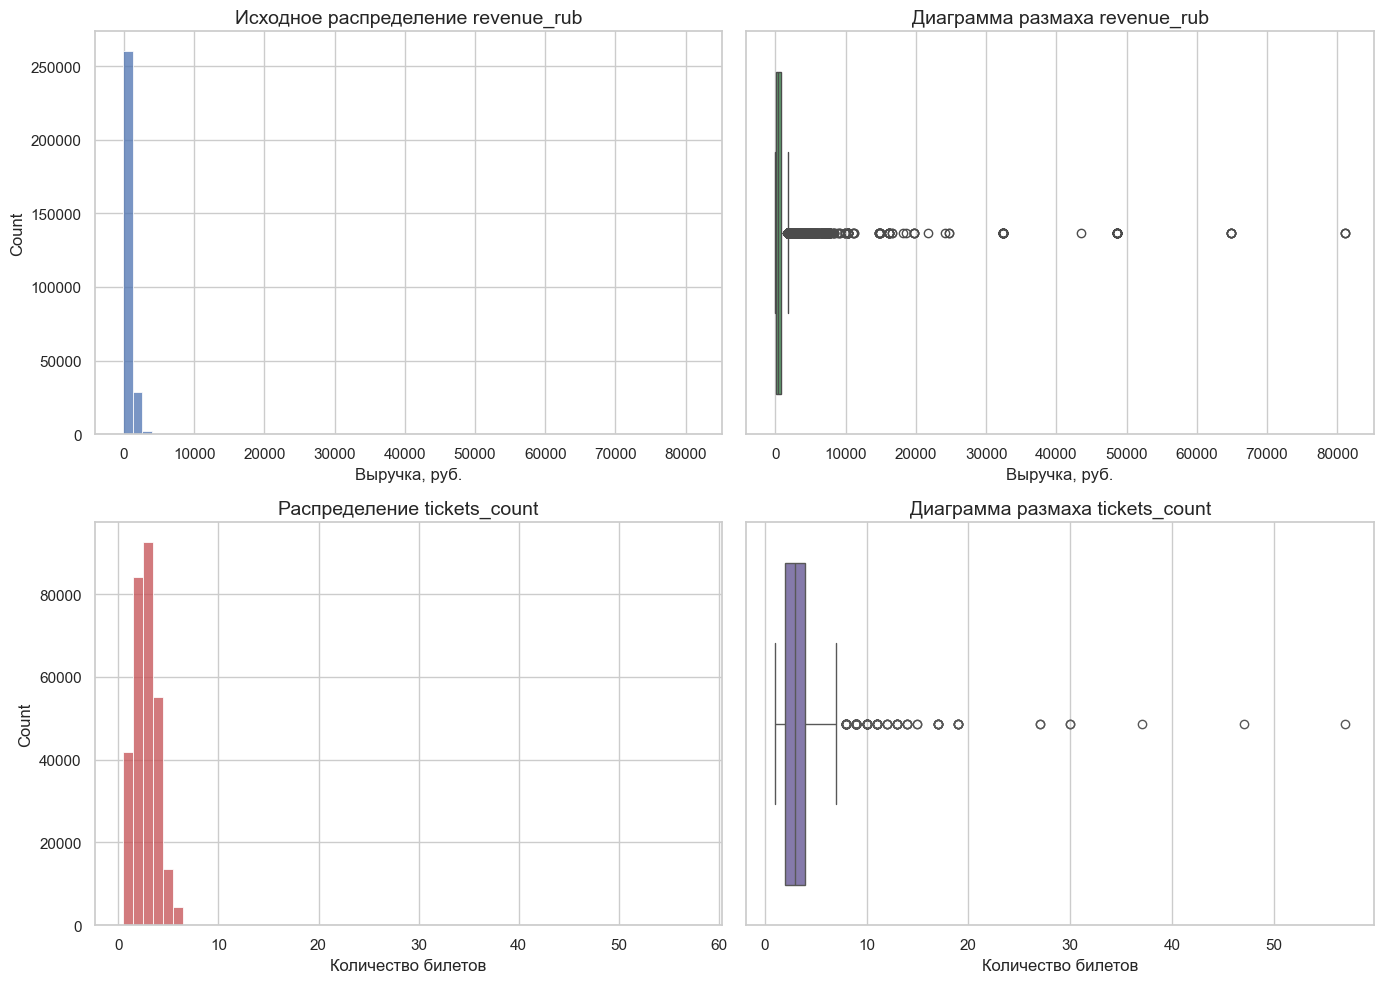

In [9]:
numeric_summary = df[['revenue_rub', 'tickets_count', 'days_since_prev']].describe(
    percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]
).round(2)
print('Статистические показатели по ключевым численным признакам:')
print(numeric_summary.to_string())

non_positive_revenue = int((df['revenue_rub'] <= 0).sum())
negative_revenue = int((df['revenue_rub'] < 0).sum())
zero_revenue = int((df['revenue_rub'] == 0).sum())
non_positive_revenue_share = non_positive_revenue / len(df) * 100
print(f"\nЗаказов с revenue_rub <= 0: {non_positive_revenue}")
print(f"Из них отрицательных: {negative_revenue}, нулевых: {zero_revenue}")
print(f"Доля заказов с revenue_rub <= 0: {non_positive_revenue_share:.2f}%")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
sns.histplot(df['revenue_rub'], bins=60, ax=axes[0, 0], color='#4C72B0')
axes[0, 0].set_title('Исходное распределение revenue_rub')
axes[0, 0].set_xlabel('Выручка, руб.')

sns.boxplot(x=df['revenue_rub'], ax=axes[0, 1], color='#55A868')
axes[0, 1].set_title('Диаграмма размаха revenue_rub')
axes[0, 1].set_xlabel('Выручка, руб.')

ticket_bins = np.arange(df['tickets_count'].min(), df['tickets_count'].max() + 2) - 0.5
sns.histplot(df['tickets_count'], bins=ticket_bins, ax=axes[1, 0], color='#C44E52')
axes[1, 0].set_title('Распределение tickets_count')
axes[1, 0].set_xlabel('Количество билетов')

sns.boxplot(x=df['tickets_count'], ax=axes[1, 1], color='#8172B3')
axes[1, 1].set_title('Диаграмма размаха tickets_count')
axes[1, 1].set_xlabel('Количество билетов')

plt.tight_layout()
plt.show()


**Короткий вывод:** По `revenue_rub` уже видно **сильную правую асимметрию** и длинный хвост. Отдельно фиксирую, что сегмент `revenue_rub <= 0` небольшой, но его нужно держать в уме при дальнейшей интерпретации. **По смыслу такие значения больше похожи не на обычные продажи, а на возвраты, корректировки, компенсационные или бесплатные сценарии**, но без отдельного продуктового признака я не могу утверждать это наверняка.


Фильтрую верхний хвост по выручке и сразу фиксирую, как это влияет на ключевые метрики.

99-й перцентиль revenue_rub: 2628.42 руб.
Отфильтровано строк по revenue_rub: 2840
Доля отфильтрованных строк: 0.97%
Рабочий объём данных после фильтрации: 289 194 строк

Как изменилась выручка после фильтрации верхнего хвоста:


,до фильтрации,после фильтрации
mean,555.109985,517.580017
median,350.329987,343.500000


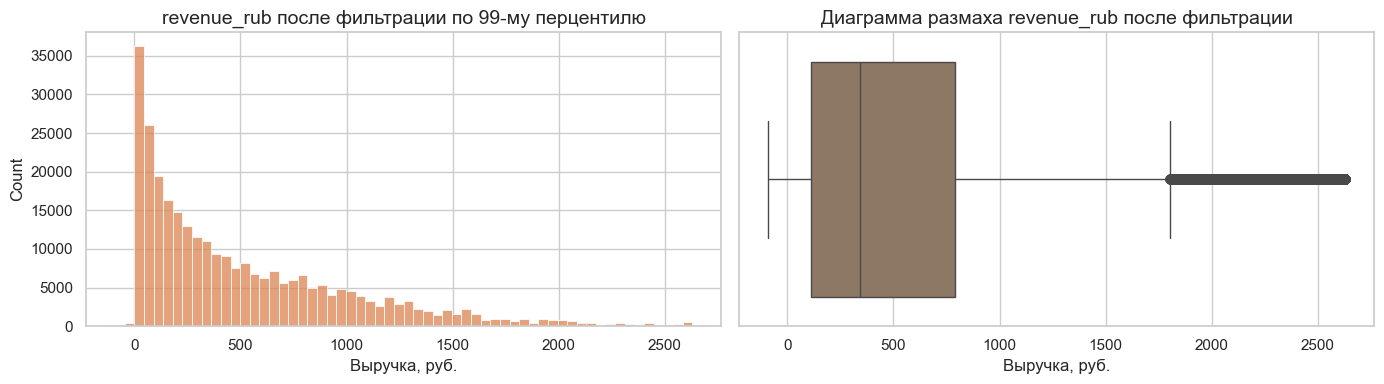

In [10]:
revenue_before_filter = df['revenue_rub'].agg(['mean', 'median']).round(2)

revenue_rub_q99 = float(df['revenue_rub'].quantile(0.99))
outliers_count = int((df['revenue_rub'] > revenue_rub_q99).sum())
df = df.loc[df['revenue_rub'] <= revenue_rub_q99].copy()
rows_after_filter = len(df)
filtered_share = (rows_before_cleaning - rows_after_filter) / rows_before_cleaning * 100

revenue_after_filter = df['revenue_rub'].agg(['mean', 'median']).round(2)
filter_effect = pd.DataFrame({
    'до фильтрации': revenue_before_filter,
    'после фильтрации': revenue_after_filter
})

print(f"99-й перцентиль revenue_rub: {revenue_rub_q99:.2f} руб.")
print(f"Отфильтровано строк по revenue_rub: {outliers_count}")
print(f"Доля отфильтрованных строк: {filtered_share:.2f}%")
print(f"Рабочий объём данных после фильтрации: {rows_after_filter:,} строк".replace(',', ' '))
print('\nКак изменилась выручка после фильтрации верхнего хвоста:')
display(filter_effect)

df_clean = df.copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(df['revenue_rub'], bins=60, ax=axes[0], color='#DD8452')
axes[0].set_title('revenue_rub после фильтрации по 99-му перцентилю')
axes[0].set_xlabel('Выручка, руб.')

sns.boxplot(x=df['revenue_rub'], ax=axes[1], color='#937860')
axes[1].set_title('Диаграмма размаха revenue_rub после фильтрации')
axes[1].set_xlabel('Выручка, руб.')

plt.tight_layout()
plt.show()


**Короткий вывод:** После отсечения верхнего хвоста по `revenue_rub` рабочая выборка почти не потеряла объём, а распределение стало стабильнее. **Поэтому фильтрацию считаю оправданной и дальше использую `df_clean`.**


In [11]:
df.describe()

,order_id,order_dt,order_ts,revenue,tickets_count,days_since_prev,event_id,revenue_rub
count,2.891940e+05,289194,289194,289194.000000,289194.000000,267397.0,289194.000000,289194.000000
mean,4.327364e+06,2024-09-01 23:56:09,2024-09-02 14:50:51.980227,571.740356,2.740669,3.219299,437742.832752,517.581543
min,1.000000e+00,2024-06-01 00:00:00,2024-06-01 00:00:42,-90.760002,1.000000,0.0,4436.000000,-90.760002
25%,2.164829e+06,2024-07-30 00:00:00,2024-07-30 13:05:22.750000,115.012501,2.000000,0.0,360640.000000,111.492498
50%,4.327512e+06,2024-09-12 00:00:00,2024-09-12 14:47:33.500000,347.304993,3.000000,0.0,497157.000000,343.500000
75%,6.490484e+06,2024-10-09 00:00:00,2024-10-09 16:18:37.750000,793.849976,3.000000,1.0,546250.000000,788.489990
max,8.653108e+06,2024-10-31 00:00:00,2024-10-31 23:59:54,13784.259766,57.000000,148.0,592325.000000,2628.419922
std,2.498067e+06,NaN,NaN,835.046448,1.162724,11.350581,147555.673374,511.902374


**Промежуточный вывод (шаг 2.2):**

- После базовой очистки данные выглядят аккуратно: пропуски остались только в `days_since_prev`.
- Типы данных привёл к более компактному виду: объём памяти сократился примерно с `216.08` МБ до `32.09` МБ.
- **Отдельно проверил дубликаты.** Полных дублей и повторов по `order_id` в данных нет.
- Широкая эвристика по совпадению `user_id`, даты, события, сервиса, выручки и числа билетов дала `53 158` кандидатов. Но после ужесточения проверки через точный `order_ts` осталось только `44` случая. **Поэтому число `53 158` нельзя трактовать как объём реальных дублей**: оно в основном показывает, что в данных много похожих заказов внутри одного дня.
- `revenue_rub` распределена с сильной правой асимметрией и длинным верхним хвостом.
- **После отсечения верхнего хвоста отдельно сравнил среднюю и медианную выручку до и после фильтрации.**
- **Отдельно отмечаю `6 153` заказов с нулевой или отрицательной выручкой**, это около `2.11%` данных. По смыслу это могут быть возвраты, корректировки, бесплатные выдачи или иные служебные операции, поэтому такие строки **не смешиваю с обычной выручкой в интерпретации**, но и не удаляю без дополнительного подтверждения.


---

### 3. Создание профиля пользователя

В будущем отдел маркетинга планирует создать модель для прогнозирования возврата пользователей. Поэтому сейчас они просят вас построить агрегированные признаки, описывающие поведение и профиль каждого пользователя.

---

**Задача 3.1.** Постройте профиль пользователя — для каждого пользователя найдите:

- дату первого и последнего заказа;
- устройство, с которого был сделан первый заказ;
- регион, в котором был сделан первый заказ;
- билетного партнёра, к которому обращались при первом заказе;
- жанр первого посещённого мероприятия (используйте поле `event_type_main`);
- общее количество заказов;
- средняя выручка с одного заказа в рублях;
- среднее количество билетов в заказе;
- среднее время между заказами.

После этого добавьте два бинарных признака:

- `is_two` — совершил ли пользователь 2 и более заказа;
- `is_five` — совершил ли пользователь 5 и более заказов.

**Рекомендация:** перед тем как строить профиль, отсортируйте данные по времени совершения заказа.

---


### 3.1 Построение профиля пользователя

Профиль пользователя строю уже на очищенных данных после шага 2.2. Сначала сортирую заказы по времени, затем для каждого пользователя выделяю признаки первого заказа и агрегирую поведение по всей доступной истории заказов.

In [12]:
orders_sorted = (
    df_clean
    .sort_values(['user_id', 'order_ts', 'order_id'])
    .copy()
    .assign(
        days_since_prev_clean=lambda x: x.groupby('user_id')['order_dt'].diff().dt.days.astype('Int16')
    )
)

first_orders = (
    orders_sorted
    .drop_duplicates(subset='user_id', keep='first')
    [['user_id', 'order_dt', 'device_type_canonical', 'region_name', 'service_name', 'event_type_main']]
    .rename(columns={
        'order_dt': 'first_order_dt',
        'device_type_canonical': 'first_device_type',
        'region_name': 'first_region_name',
        'service_name': 'first_service_name',
        'event_type_main': 'first_event_type_main'
    })
)

user_profile = (
    orders_sorted
    .groupby('user_id', as_index=False)
    .agg(
        last_order_dt=('order_dt', 'max'),
        total_orders=('order_id', 'count'),
        avg_revenue_rub=('revenue_rub', 'mean'),
        avg_tickets_count=('tickets_count', 'mean'),
        avg_days_between_orders=('days_since_prev_clean', 'mean')
    )
    .merge(first_orders, on='user_id', how='left')
    .loc[:, [
        'user_id',
        'first_order_dt',
        'last_order_dt',
        'first_device_type',
        'first_region_name',
        'first_service_name',
        'first_event_type_main',
        'total_orders',
        'avg_revenue_rub',
        'avg_tickets_count',
        'avg_days_between_orders'
    ]]
    .sort_values('user_id')
    .reset_index(drop=True)
    .assign(
        total_orders=lambda x: x['total_orders'].astype('int16'),
        avg_revenue_rub=lambda x: x['avg_revenue_rub'].round(2).astype('float32'),
        avg_tickets_count=lambda x: x['avg_tickets_count'].round(2).astype('float32'),
        avg_days_between_orders=lambda x: x['avg_days_between_orders'].astype('float64').round(2).astype('float32'),
        is_two=lambda x: (x['total_orders'] >= 2).astype('int8'),
        is_five=lambda x: (x['total_orders'] >= 5).astype('int8')
    )
)

for col in ['first_device_type', 'first_region_name', 'first_service_name', 'first_event_type_main']:
    user_profile[col] = user_profile[col].astype('category')

user_profile_base = user_profile.copy()

profile_check = pd.Series({
    'orders_in_clean_data': len(df_clean),
    'users_in_clean_data': df_clean['user_id'].nunique(),
    'users_in_profile': len(user_profile),
    'sum_total_orders': int(user_profile['total_orders'].sum()),
    'single_order_users': int((user_profile['total_orders'] == 1).sum()),
    'share_is_two': round(float(user_profile['is_two'].mean()), 4),
    'share_is_five': round(float(user_profile['is_five'].mean()), 4)
})

print('Контроль агрегирования профиля:')
print(profile_check.to_string())

user_profile.head()


Контроль агрегирования профиля:
orders_in_clean_data    289194.0000
users_in_clean_data      21920.0000
users_in_profile         21920.0000
sum_total_orders        289194.0000
single_order_users        8381.0000
share_is_two                 0.6177
share_is_five                0.2901


,user_id,first_order_dt,last_order_dt,first_device_type,first_region_name,first_service_name,first_event_type_main,total_orders,avg_revenue_rub,avg_tickets_count,avg_days_between_orders,is_two,is_five
0,0002849b70a3ce2,2024-08-20,2024-08-20,mobile,Каменевский регион,Край билетов,театр,1,1521.939941,4.00,NaN,0,0
1,0005ca5e93f2cf4,2024-07-23,2024-10-06,mobile,Каменевский регион,Мой билет,выставки,2,774.010010,3.00,75.0,1,0
2,000898990054619,2024-07-13,2024-10-23,mobile,Североярская область,Лови билет!,другое,3,767.210022,2.67,51.0,1,0
3,00096d1f542ab2b,2024-08-15,2024-08-15,desktop,Каменевский регион,Край билетов,театр,1,917.830017,4.00,NaN,0,0
4,000a55a418c128c,2024-09-29,2024-10-15,mobile,Поленовский край,Лучшие билеты,театр,2,61.310001,1.50,16.0,1,0


**Результат блока:** Профиль пользователя собран корректно: число пользователей в профиле совпадает с числом уникальных `user_id` в очищенных данных, а сумма `total_orders` совпадает с числом заказов в `df_clean`. Значит, агрегирование прошло без потерь и перекосов.


**Промежуточный вывод (шаг 3.1):**

- На этом шаге у меня уже готов полноценный пользовательский профиль: я собрал признаки первого заказа и агрегаты по всей истории покупок на очищенных данных.
- После фильтрации выбросов по `revenue_rub` в профиле осталось `21 920` пользователей. Потерь при агрегировании нет: сумма `total_orders` совпадает с числом строк в `df_clean` и составляет `289 194`.
- Для каждого пользователя зафиксировал дату первого и последнего заказа, характеристики первого заказа, число заказов, среднюю выручку в рублях, среднее число билетов и средний интервал между покупками.
- Показатель `avg_days_between_orders` пересчитал уже на очищенной последовательности заказов после фильтрации по `revenue_rub`, чтобы интервалы не ссылались на исключённые заказы.
- Дополнительно создал бинарные признаки `is_two` и `is_five`, которые дальше удобно использовать для анализа возврата и многократных покупок.
- Базовую версию профиля сохранил отдельно в `user_profile_base`, чтобы на следующих шагах можно было спокойно проверять аномалии и при необходимости делать фильтрации без повторной сборки профиля.


---

**Задача 3.2.** Прежде чем проводить исследовательский анализ данных и делать выводы, важно понять, с какими данными вы работаете: насколько они репрезентативны и нет ли в них аномалий.

Используя данные о профилях пользователей, рассчитайте:

- общее число пользователей в выборке;
- среднюю выручку с одного заказа;
- долю пользователей, совершивших 2 и более заказа;
- долю пользователей, совершивших 5 и более заказов.

Также изучите статистические показатели:

- по общему числу заказов;
- по среднему числу билетов в заказе;
- по среднему количеству дней между покупками.

По результатам оцените данные: достаточно ли их по объёму, есть ли аномальные значения в данных о количестве заказов и среднем количестве билетов?

Если вы найдёте аномальные значения, опишите их и примите обоснованное решение о том, как с ними поступить:

- Оставить и учитывать их при анализе?
- Отфильтровать данные по какому-то значению, например, по 95-му или 99-му перцентилю?

Если вы проведёте фильтрацию, то вычислите объём отфильтрованных данных и выведите статистические показатели по обновлённому датасету.

Сначала оцениваю объём профиля и ключевые метрики.

In [13]:
user_profile_full = user_profile_base.copy()
user_profile = user_profile_base.copy()

profile_overview = pd.Series({
    'users_in_profile': len(user_profile),
    'avg_revenue_per_order_rub': round(float(user_profile['avg_revenue_rub'].mean()), 2),
    'share_is_two_pct': round(float(user_profile['is_two'].mean() * 100), 2),
    'share_is_five_pct': round(float(user_profile['is_five'].mean() * 100), 2)
})

profile_stats = user_profile[['total_orders', 'avg_tickets_count', 'avg_days_between_orders']].describe(
    percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]
).round(2)

anomaly_overview = pd.DataFrame([
    {
        'metric': 'total_orders',
        'q95': float(user_profile['total_orders'].quantile(0.95)),
        'q99': float(user_profile['total_orders'].quantile(0.99)),
        'max': float(user_profile['total_orders'].max()),
        'rows_above_q99': int((user_profile['total_orders'] > user_profile['total_orders'].quantile(0.99)).sum()),
        'share_above_q99_pct': round(float((user_profile['total_orders'] > user_profile['total_orders'].quantile(0.99)).mean() * 100), 2)
    },
    {
        'metric': 'avg_tickets_count',
        'q95': float(user_profile['avg_tickets_count'].quantile(0.95)),
        'q99': float(user_profile['avg_tickets_count'].quantile(0.99)),
        'max': float(user_profile['avg_tickets_count'].max()),
        'rows_above_q99': int((user_profile['avg_tickets_count'] > user_profile['avg_tickets_count'].quantile(0.99)).sum()),
        'share_above_q99_pct': round(float((user_profile['avg_tickets_count'] > user_profile['avg_tickets_count'].quantile(0.99)).mean() * 100), 2)
    }
]).round(2)

print('Ключевые метрики по полному профилю:')
print(profile_overview.to_string())

print('\nСтатистические показатели профиля:')
print(profile_stats.to_string())

print('\nКраткая проверка на аномальные значения:')
print(anomaly_overview.to_string(index=False))

Ключевые метрики по полному профилю:
users_in_profile             21920.00
avg_revenue_per_order_rub      543.46
share_is_two_pct                61.77
share_is_five_pct               29.01

Статистические показатели профиля:
       total_orders  avg_tickets_count  avg_days_between_orders
count      21920.00           21920.00                 13539.00
mean          13.19               2.74                    15.88
std          122.13               0.91                    22.29
min            1.00               1.00                     0.00
1%             1.00               1.00                     0.00
5%             1.00               1.00                     0.00
25%            1.00               2.00                     1.00
50%            2.00               2.75                     8.07
75%            5.00               3.07                    20.50
95%           31.00               4.00                    61.50
99%          152.00               5.00                   112.00
max    

**Результат блока:** На полном профиле вижу `21 920` пользователей. Доля пользователей с `2+` заказами составляет `61.77%`, с `5+` заказами — `29.01%`, а средняя выручка на уровне пользовательского признака — `543.46` руб. Уже здесь видно, что данных достаточно для дальнейшего анализа.


Смотрю распределения по числу заказов и среднему числу билетов.

Для `total_orders` использую `log(1 + x)` только для визуализации. Распределение сильно скошено вправо: без логарифма основная масса пользователей сжимается у нуля, и хвост почти не читается.

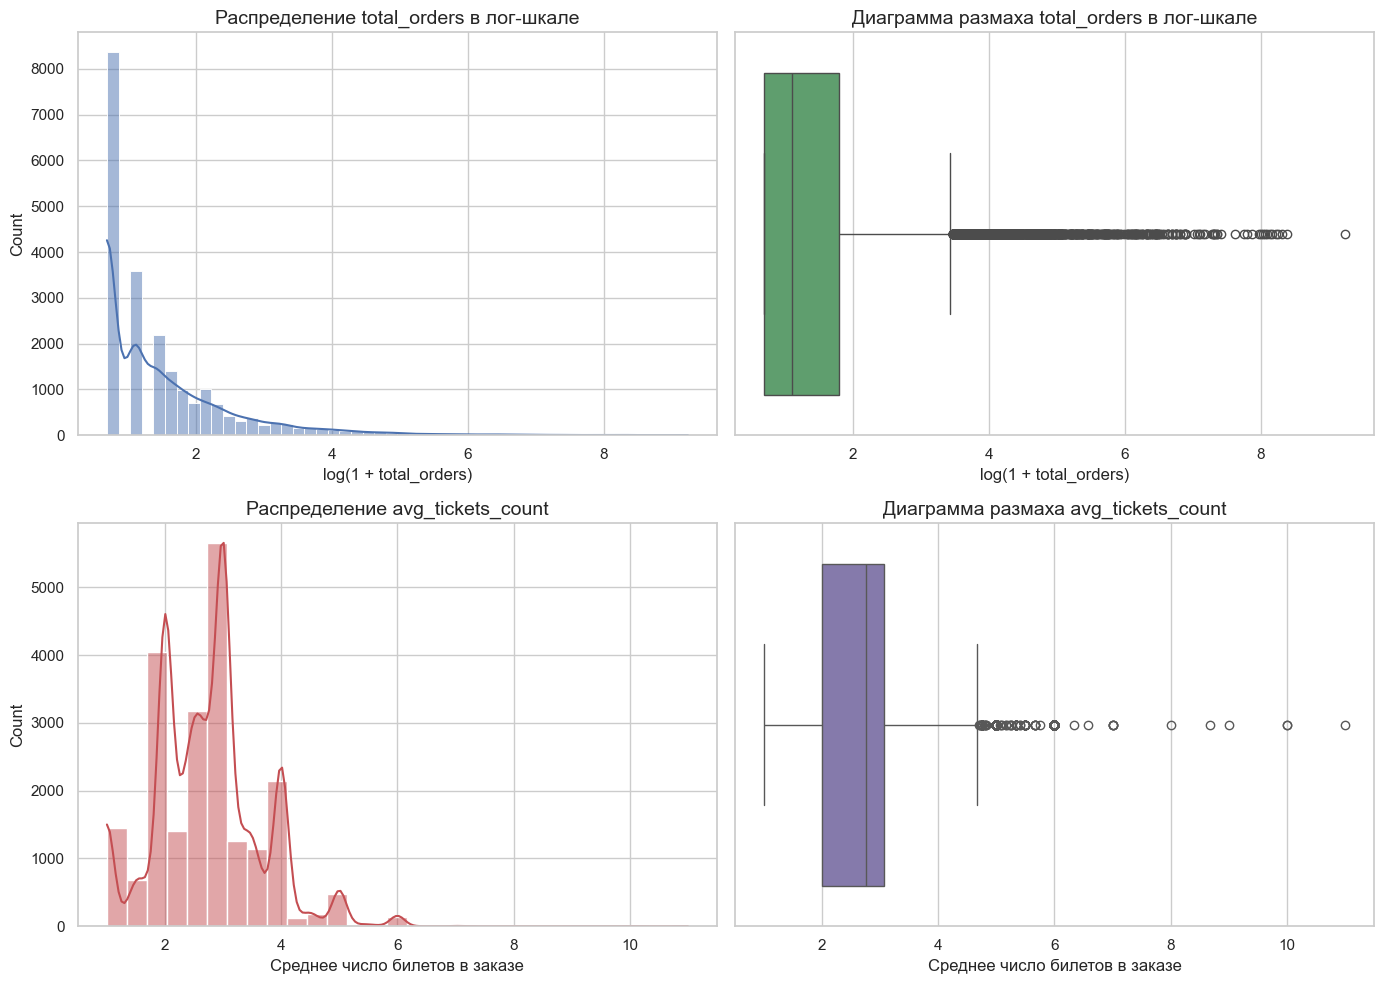

In [14]:
log_total_orders = np.log1p(user_profile['total_orders'])

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.histplot(log_total_orders, bins=50, kde=True, ax=axes[0, 0], color='#4C72B0')
axes[0, 0].set_title('Распределение total_orders в лог-шкале')
axes[0, 0].set_xlabel('log(1 + total_orders)')

sns.boxplot(x=log_total_orders, ax=axes[0, 1], color='#55A868')
axes[0, 1].set_title('Диаграмма размаха total_orders в лог-шкале')
axes[0, 1].set_xlabel('log(1 + total_orders)')

ticket_bins = np.linspace(user_profile['avg_tickets_count'].min(), user_profile['avg_tickets_count'].max(), 30)
sns.histplot(user_profile['avg_tickets_count'], bins=ticket_bins, kde=True, ax=axes[1, 0], color='#C44E52')
axes[1, 0].set_title('Распределение avg_tickets_count')
axes[1, 0].set_xlabel('Среднее число билетов в заказе')

sns.boxplot(x=user_profile['avg_tickets_count'], ax=axes[1, 1], color='#8172B3')
axes[1, 1].set_title('Диаграмма размаха avg_tickets_count')
axes[1, 1].set_xlabel('Среднее число билетов в заказе')

plt.tight_layout()
plt.show()

**Результат блока:** По графикам `total_orders` выделяется длинным правым хвостом даже после логарифмирования. `avg_tickets_count` выглядит заметно спокойнее и в основном сосредоточен около `2-3` билетов.


**Короткий вывод:** Уже по визуализации видно, что возможные аномалии сосредоточены прежде всего в `total_orders`, а не в `avg_tickets_count`. Поэтому дальше количественно проверяю хвост по числу заказов и оцениваю, нужен ли дополнительный отсев профилей.


Теперь количественно проверяю хвост по `total_orders` и оцениваю эффект фильтрации.

In [15]:
total_orders_q99 = float(user_profile['total_orders'].quantile(0.99))
removed_users = int((user_profile['total_orders'] > total_orders_q99).sum())
removed_orders = int(user_profile.loc[user_profile['total_orders'] > total_orders_q99, 'total_orders'].sum())

user_profile_eda = user_profile.loc[user_profile['total_orders'] <= total_orders_q99].copy()
user_profile = user_profile_eda.copy()

comparison_summary = pd.DataFrame({
    'before_filter': {
        'users': len(user_profile_full),
        'avg_revenue_per_order_rub': round(float(user_profile_full['avg_revenue_rub'].mean()), 2),
        'share_is_two_pct': round(float(user_profile_full['is_two'].mean() * 100), 2),
        'share_is_five_pct': round(float(user_profile_full['is_five'].mean() * 100), 2),
        'mean_total_orders': round(float(user_profile_full['total_orders'].mean()), 2),
        'mean_avg_tickets_count': round(float(user_profile_full['avg_tickets_count'].mean()), 2),
        'mean_avg_days_between_orders': round(float(user_profile_full['avg_days_between_orders'].dropna().mean()), 2)
    },
    'after_filter': {
        'users': len(user_profile),
        'avg_revenue_per_order_rub': round(float(user_profile['avg_revenue_rub'].mean()), 2),
        'share_is_two_pct': round(float(user_profile['is_two'].mean() * 100), 2),
        'share_is_five_pct': round(float(user_profile['is_five'].mean() * 100), 2),
        'mean_total_orders': round(float(user_profile['total_orders'].mean()), 2),
        'mean_avg_tickets_count': round(float(user_profile['avg_tickets_count'].mean()), 2),
        'mean_avg_days_between_orders': round(float(user_profile['avg_days_between_orders'].dropna().mean()), 2)
    }
})

updated_profile_stats = user_profile[['total_orders', 'avg_tickets_count', 'avg_days_between_orders']].describe(
    percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]
).round(2)

print(f'Порог фильтрации total_orders по 99-му перцентилю: {total_orders_q99:.0f}')
print(f'Удалено профилей: {removed_users} ({removed_users / len(user_profile_full) * 100:.2f}%)')
print(f'Заказов в удалённых профилях: {removed_orders:,}'.replace(',', ' '))
print(f"Доля заказов в удалённых профилях: {removed_orders / user_profile_full['total_orders'].sum() * 100:.2f}%")
print('\nСравнение метрик до и после фильтрации:')
print(comparison_summary.to_string())

print('\nОбновлённые статистические показатели профиля:')
print(updated_profile_stats.to_string())



Порог фильтрации total_orders по 99-му перцентилю: 152
Удалено профилей: 219 (1.00%)
Заказов в удалённых профилях: 148 283
Доля заказов в удалённых профилях: 51.27%

Сравнение метрик до и после фильтрации:
                              before_filter  after_filter
users                              21920.00      21701.00
avg_revenue_per_order_rub            543.46        543.77
share_is_two_pct                      61.77         61.38
share_is_five_pct                     29.01         28.29
mean_total_orders                     13.19          6.49
mean_avg_tickets_count                 2.74          2.74
mean_avg_days_between_orders          15.88         16.14

Обновлённые статистические показатели профиля:
       total_orders  avg_tickets_count  avg_days_between_orders
count      21701.00           21701.00                 13320.00
mean           6.49               2.74                    16.14
std           14.27               0.92                    22.38
min            1.00       

**Результат блока:** После отсечения профилей выше `99`-го перцентиля по `total_orders` из рабочего анализа уходят `219` пользователей. Это около `1%` профиля, но на них приходится больше половины всех заказов, поэтому для EDA такое решение выглядит оправданным.


**Промежуточный вывод (шаг 3.2):**

- По объёму данных выборка выглядит уверенно: даже после очистки полный профиль содержит `21 920` пользователей.
- По полному профилю средняя выручка с заказа на уровне пользовательского признака `avg_revenue_rub` составляет `543.46` руб., доля пользователей с `2` и более заказами — `61.77%`, с `5` и более заказами — `29.01%`.
- Самая заметная аномалия сосредоточена в `total_orders`: медиана равна `2`, но максимум достигает `10 243` заказов, а верхний `1%` профилей начинается уже с `152` заказов. При этом эти `219` пользователей формируют `148 283` заказов, то есть более `51%` всех заказов в профиле. Для пользовательского анализа такой хвост выглядит слишком тяжёлым.
- Поэтому для последующего EDA отфильтровал профили выше `99`-го перцентиля по `total_orders`. После фильтрации осталось `21 701` пользователь, а рабочий профиль сохранён в `user_profile`.
- Эффект фильтрации отдельно проверил по сводной таблице до и после отсечения хвоста: базовые метрики изменились умеренно, а сама выборка стала заметно устойчивее для дальнейшей интерпретации.
- По `avg_tickets_count` экстремумы выражены намного слабее: `99`-й перцентиль равен `5`, максимум — `11`. Такие значения больше похожи на редкие, но возможные групповые покупки, поэтому этот признак оставляю без дополнительной фильтрации.
- Средний интервал между покупками теперь рассчитан на согласованной очищенной последовательности заказов, поэтому дальше выводы по удержанию опираются на уже аккуратную рабочую выборку.


---

### 4. Исследовательский анализ данных

Следующий этап — исследование признаков, влияющих на возврат пользователей, то есть на совершение повторного заказа. Для этого используйте профили пользователей.



#### 4.1. Исследование признаков первого заказа и их связи с возвращением на платформу

Исследуйте признаки, описывающие первый заказ пользователя, и выясните, влияют ли они на вероятность возвращения пользователя.

---

**Задача 4.1.1.** Изучите распределение пользователей по признакам.

- Сгруппируйте пользователей:
    - по типу их первого мероприятия;
    - по типу устройства, с которого совершена первая покупка;
    - по региону проведения мероприятия из первого заказа;
    - по билетному оператору, продавшему билеты на первый заказ.
- Подсчитайте общее количество пользователей в каждом сегменте и их долю в разрезе каждого признака. Сегмент — это группа пользователей, объединённых определённым признаком, то есть объединённые принадлежностью к категории. Например, все клиенты, сделавшие первый заказ с мобильного телефона, — это сегмент.
- Ответьте на вопрос: равномерно ли распределены пользователи по сегментам или есть выраженные «точки входа» — сегменты с наибольшим числом пользователей?

---


In [16]:
segment_features = {
    'first_event_type_main': {'label': 'тип первого мероприятия', 'top_n': 8},
    'first_device_type': {'label': 'устройство первого заказа', 'top_n': 3},
    'first_region_name': {'label': 'регион первого заказа', 'top_n': 10},
    'first_service_name': {'label': 'билетный оператор первого заказа', 'top_n': 10}
}

segment_distributions = {}
segment_overview_rows = []

for feature, meta in segment_features.items():
    dist = (
        user_profile[feature]
        .astype('string')
        .value_counts(dropna=False)
        .rename_axis('segment')
        .reset_index(name='users')
    )
    dist['share_pct'] = (dist['users'].astype('float64') / len(user_profile) * 100).round(2)
    segment_distributions[feature] = dist

    shown_share_pct = round(float(dist['share_pct'].head(meta['top_n']).sum()), 2)
    outside_share_pct = round(float(100 - shown_share_pct), 2)

    segment_overview_rows.append({
        'Признак': meta['label'],
        'Число сегментов': len(dist),
        'Крупнейший сегмент': dist.loc[0, 'segment'],
        'Пользователей в крупнейшем сегменте': int(dist.loc[0, 'users']),
        'Доля крупнейшего сегмента, %': float(dist.loc[0, 'share_pct']),
        'Доля топ-3 сегментов, %': round(float(dist['share_pct'].head(3).sum()), 2),
        'Доля показанных сегментов, %': shown_share_pct,
        'Вне обзора, %': outside_share_pct
    })

segment_overview = pd.DataFrame(segment_overview_rows)
segment_overview


,Признак,Число сегментов,Крупнейший сегмент,Пользователей в крупнейшем сегменте,"Доля крупнейшего сегмента, %","Доля топ-3 сегментов, %","Доля показанных сегментов, %","Вне обзора, %"
0,тип первого мероприятия,8,концерты,9572,44.11,88.77,100.00,0.00
1,устройство первого заказа,3,mobile,17899,82.48,100.00,100.00,0.00
2,регион первого заказа,81,Каменевский регион,7104,32.74,55.80,71.96,28.04
3,билетный оператор первого заказа,34,Билеты без проблем,5208,24.00,50.69,90.42,9.58


**Результат блока:** Точки входа уже на сводной таблице выглядят неравномерно. Самые крупные сегменты есть по всем четырём признакам, значит дальше действительно имеет смысл сравнивать их не только по размеру, но и по возврату. **Для признаков с неполным выводом сразу фиксирую охват обзора: топ-10 регионов покрывают `71.97%` пользователей, а топ-10 операторов — `90.41%`.**


Показываю сами сегменты. Для регионов и операторов оставляю только 10 крупнейших категорий, чтобы вывод читался компактно, и **сразу фиксирую, какую долю выборки они покрывают**.


In [17]:
for feature, meta in segment_features.items():
    dist = segment_distributions[feature]
    dist_to_show = dist if len(dist) <= meta['top_n'] else dist.head(meta['top_n'])
    shown_share_pct = round(float(dist_to_show['share_pct'].sum()), 2)
    outside_share_pct = round(float(100 - shown_share_pct), 2)

    print(f"\nРаспределение по признаку: {meta['label']}")
    print(
        f"Показанные {len(dist_to_show)} сегментов покрывают {shown_share_pct}% пользователей. "
        f"Вне обзора остаётся {outside_share_pct}%."
    )
    print(dist_to_show.to_string(index=False))



Распределение по признаку: тип первого мероприятия
Показанные 8 сегментов покрывают 100.0% пользователей. Вне обзора остаётся 0.0%.
 segment  users  share_pct
концерты   9572      44.11
  другое   5432      25.03
   театр   4259      19.63
 стендап   1107       5.10
   спорт    797       3.67
выставки    414       1.91
    ёлки     93       0.43
   фильм     27       0.12

Распределение по признаку: устройство первого заказа
Показанные 3 сегментов покрывают 100.0% пользователей. Вне обзора остаётся 0.0%.
segment  users  share_pct
 mobile  17899      82.48
desktop   3704      17.07
 tablet     98       0.45

Распределение по признаку: регион первого заказа
Показанные 10 сегментов покрывают 71.96% пользователей. Вне обзора остаётся 28.04%.
             segment  users  share_pct
  Каменевский регион   7104      32.74
Североярская область   3781      17.42
 Широковская область   1225       5.64
    Озернинский край    677       3.12
Малиновоярский округ    525       2.42
    Шанырский рег

Строю графики, чтобы быстро увидеть концентрацию пользователей и основные точки входа.

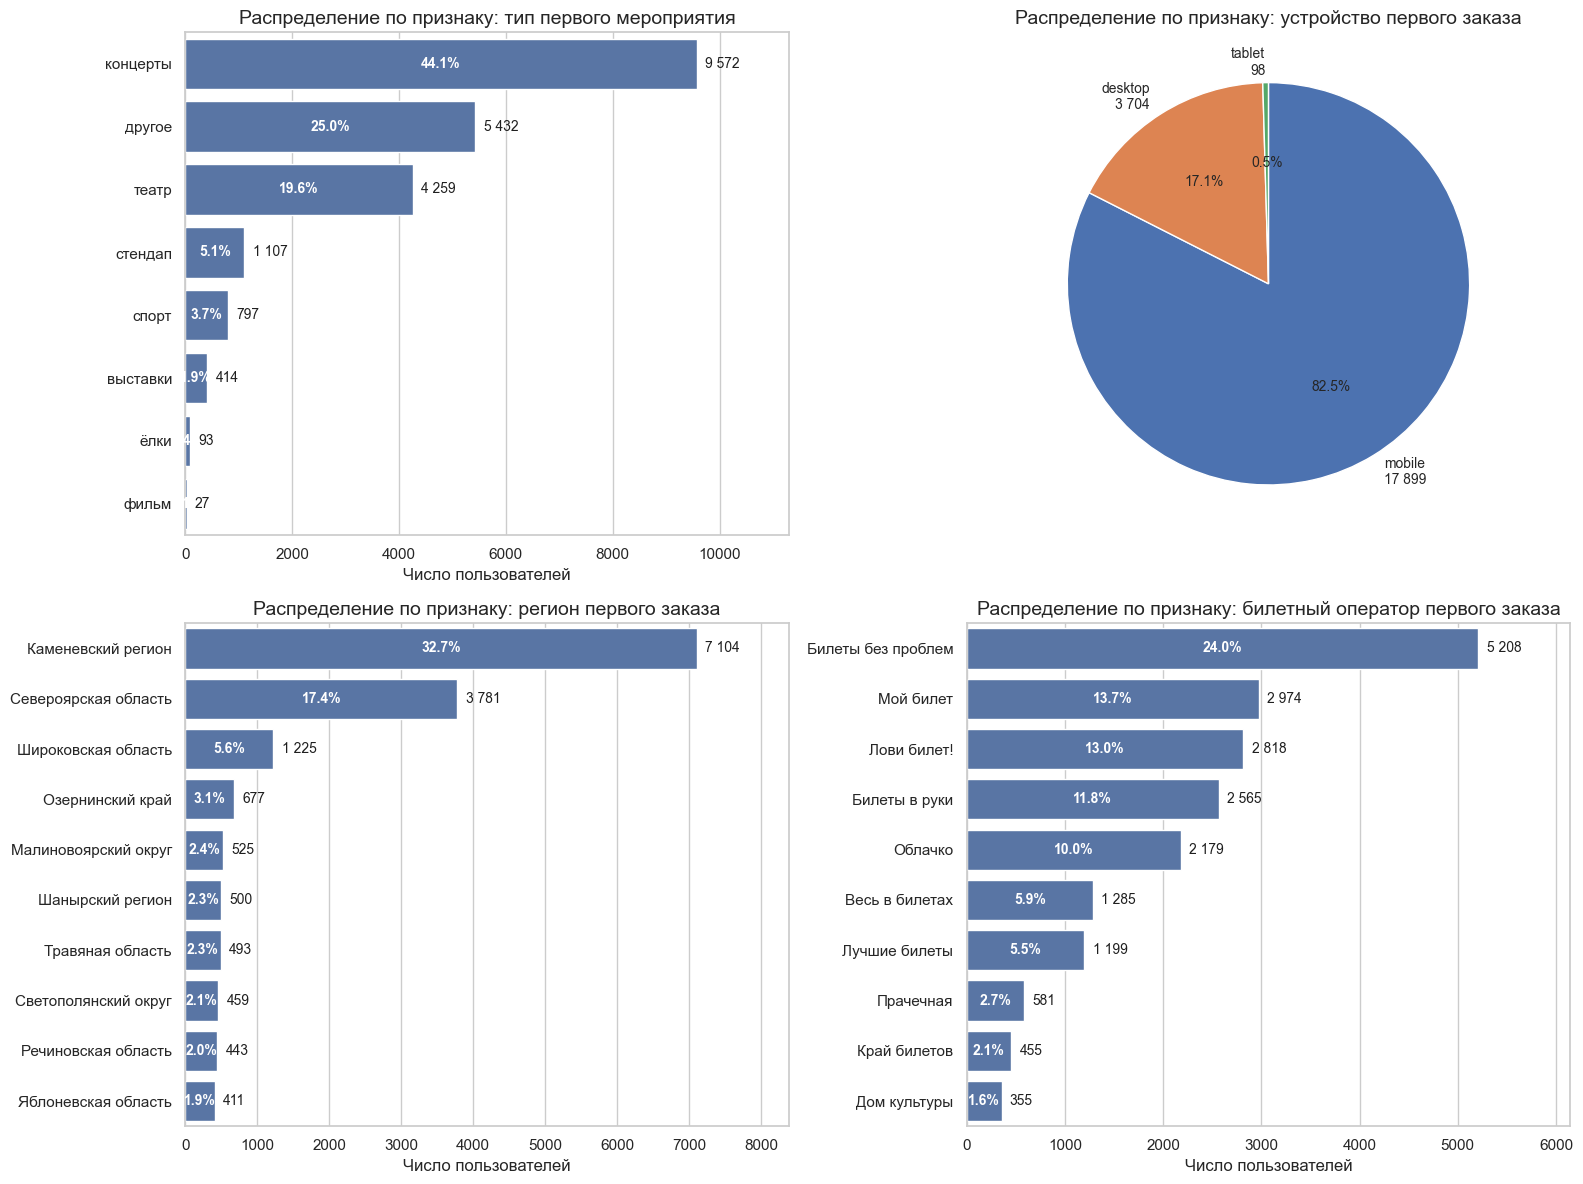

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
plot_order = [
    'first_event_type_main',
    'first_device_type',
    'first_region_name',
    'first_service_name'
]

for ax, feature in zip(axes.flat, plot_order):
    meta = segment_features[feature]
    plot_data = segment_distributions[feature].head(meta['top_n']).copy()

    if feature == 'first_device_type':
        device_labels = [
            f"{segment}\n{users:,}".replace(',', ' ')
            for segment, users in zip(plot_data['segment'], plot_data['users'])
        ]
        ax.pie(
            plot_data['users'],
            labels=device_labels,
            autopct='%1.1f%%',
            startangle=90,
            counterclock=False,
            wedgeprops={'edgecolor': 'white', 'linewidth': 1},
            textprops={'fontsize': 10}
        )
        ax.set_title(f"Распределение по признаку: {meta['label']}")
    else:
        sns.barplot(data=plot_data, x='users', y='segment', ax=ax, color='#4C72B0')
        ax.set_title(f"Распределение по признаку: {meta['label']}")
        ax.set_xlabel('Число пользователей')
        ax.set_ylabel('')
        ax.margins(x=0.18)

        bars = ax.patches
        share_labels = [f"{share:.1f}%" for share in plot_data['share_pct']]
        user_labels = [f"{users:,}".replace(',', ' ') for users in plot_data['users']]

        for bar, share_label, user_label in zip(bars, share_labels, user_labels):
            width = bar.get_width()
            y = bar.get_y() + bar.get_height() / 2

            ax.annotate(
                share_label,
                xy=(width / 2, y),
                ha='center',
                va='center',
                color='white',
                fontsize=10,
                fontweight='bold'
            )

            ax.annotate(
                user_label,
                xy=(width, y),
                xytext=(6, 0),
                textcoords='offset points',
                ha='left',
                va='center',
                color='#1f1f1f',
                fontsize=10
            )

plt.tight_layout()
plt.show()


**Промежуточный вывод (шаг 4.1.1):**

- Для анализа использую рабочий профиль `user_profile`, в котором после фильтрации аномально активных пользователей осталось `21 701` наблюдение.
- В целом распределение по сегментам выглядит **неравномерным**: у платформы есть несколько явно доминирующих точек первого контакта, а остальная часть сегментов уже заметно более нишевая.
- По типу первого мероприятия сильнее всего выделяются `концерты`, `другое` и `театр`. Именно они формируют основной поток новых пользователей: вместе это `88.77%` профиля. Значит, первый контакт чаще всего происходит через самые массовые и понятные сценарии досуга, а остальные категории выглядят уже как более узкие направления.
- По устройству картина ещё более выраженная: первый заказ почти всегда совершается с `mobile` (`82.48%`). `Desktop` остаётся важным, но уже вторичным каналом (`17.07%`), а `tablet` практически не влияет на общую структуру спроса. Похоже, что вход в сервис у большинства пользователей связан с быстрым и удобным мобильным сценарием.
- По регионам и операторам структура тоже концентрированная, но не настолько жёсткая, как по устройству. Здесь уже видно несколько крупных центров притяжения, после которых начинается более дробный хвост. Крупнейший регион — `Каменевский регион` (`32.74%`), а крупнейший оператор — `Билеты без проблем` (`24.00%`). Топ-3 региона дают `55.80%` пользователей, топ-3 оператора — `50.69%`.
- **Чтобы не создавать ложное ощущение полноты обзора, отдельно фиксирую охват показанных сегментов:** на графике и в таблице топ-10 регионов покрывают только `71.97%` пользователей, то есть ещё `28.03%` остаётся за пределами визуализации. По операторам охват заметно выше — `90.41%`, вне обзора остаётся `9.59%`.
- В итоге я бы описал эту картину так: у сервиса есть понятное «ядро» первого входа — мобильные устройства, массовые жанры, несколько самых активных регионов и крупных операторов. Всё остальное в большей степени дополняет это ядро, а не определяет его. Именно поэтому дальше логично смотреть не только на размер сегмента, но и на то, насколько хорошо такие точки входа конвертируются в возврат.


---

**Задача 4.1.2.** Проанализируйте возвраты пользователей:

- Для каждого сегмента вычислите долю пользователей, совершивших два и более заказа.
- Визуализируйте результат подходящим графиком. Если сегментов слишком много, то поместите на график только 10 сегментов с наибольшим количеством пользователей. Такое возможно с сегментами по региону и по билетному оператору.
- Ответьте на вопросы:
    - Какие сегменты пользователей чаще возвращаются на Яндекс Афишу?
    - Наблюдаются ли успешные «точки входа» — такие сегменты, в которых пользователи чаще совершают повторный заказ, чем в среднем по выборке?

При интерпретации результатов учитывайте размер сегментов: если в сегменте мало пользователей (например, десятки), то доли могут быть нестабильными и недостоверными, то есть показывать широкую вариацию значений.

---


Считаю долю возврата по каждому сегменту. За возврат принимаю пользователя, который сделал 2 и более заказа, то есть использую уже подготовленный признак `is_two`.

In [19]:
overall_repeat_rate = round(float(user_profile['is_two'].mean() * 100), 2)

segment_return_tables = {}
segment_return_overview_rows = []

for feature, meta in segment_features.items():
    result = (
        user_profile.groupby(feature, dropna=False)
        .agg(
            users=('user_id', 'count'),
            repeat_users=('is_two', 'sum'),
            repeat_rate_pct=('is_two', lambda x: x.mean() * 100)
        )
        .reset_index()
        .rename(columns={feature: 'segment'})
        .sort_values(['users', 'repeat_rate_pct'], ascending=[False, False])
    )

    result['repeat_rate_pct'] = result['repeat_rate_pct'].round(2)
    result['above_avg'] = np.where(result['repeat_rate_pct'] > overall_repeat_rate, 'выше среднего', 'не выше среднего')
    segment_return_tables[feature] = result

    reliable = result[result['users'] >= 100].sort_values(['repeat_rate_pct', 'users'], ascending=[False, False])
    best_reliable = reliable.iloc[0] if not reliable.empty else result.iloc[0]

    shown_users_share_pct = round(float(result['users'].head(meta['top_n']).sum() / result['users'].sum() * 100), 2)
    outside_users_share_pct = round(float(100 - shown_users_share_pct), 2)

    segment_return_overview_rows.append({
        'Признак': meta['label'],
        'Средняя доля 2+ заказов, %': overall_repeat_rate,
        'Крупнейший сегмент': result.iloc[0]['segment'],
        'Возврат в крупнейшем сегменте, %': float(result.iloc[0]['repeat_rate_pct']),
        'Лучший достаточно крупный сегмент': best_reliable['segment'],
        'Возврат в лучшем крупном сегменте, %': float(best_reliable['repeat_rate_pct']),
        'Доля показанных сегментов, %': shown_users_share_pct,
        'Вне обзора, %': outside_users_share_pct
    })

segment_return_overview = pd.DataFrame(segment_return_overview_rows)
segment_return_overview

,Признак,"Средняя доля 2+ заказов, %",Крупнейший сегмент,"Возврат в крупнейшем сегменте, %",Лучший достаточно крупный сегмент,"Возврат в лучшем крупном сегменте, %","Доля показанных сегментов, %","Вне обзора, %"
0,тип первого мероприятия,61.38,концерты,61.89,выставки,64.01,100.00,0.00
1,устройство первого заказа,61.38,mobile,60.90,desktop,63.88,100.00,0.00
2,регион первого заказа,61.38,Каменевский регион,62.51,Шанырский регион,67.20,71.97,28.03
3,билетный оператор первого заказа,61.38,Билеты без проблем,60.48,Край билетов,65.27,90.41,9.59


**Результат блока:** Базовый ориентир для сравнения сегментов готов: средняя доля пользователей с `2+` заказами по рабочему профилю составляет `61.38%`. Ниже уже можно смотреть, какие сегменты оказываются сильнее или слабее этого уровня. **Для неполных списков сегментов сразу сохраняю и охват выборки: по регионам это `71.97%`, по операторам — `90.41%`.**


Показываю точные значения. Для регионов и операторов вывожу только 10 самых крупных сегментов и **не просто отмечаю это словами, а сразу фиксирую охват**: **топ-10 регионов покрывают `71.97%` пользователей, а топ-10 операторов — `90.41%`**. Так видно, насколько велика часть данных вне обзора.


In [20]:
for feature, meta in segment_features.items():
    full_result = segment_return_tables[feature].copy()
    result = full_result if len(full_result) <= meta['top_n'] else full_result.head(meta['top_n'])
    shown_users_share_pct = round(float(result['users'].sum() / full_result['users'].sum() * 100), 2)
    outside_users_share_pct = round(float(100 - shown_users_share_pct), 2)

    print(f"\nВозвраты по признаку: {meta['label']}")
    print(
        f"Показанные {len(result)} сегментов покрывают {shown_users_share_pct}% пользователей. "
        f"Вне обзора остаётся {outside_users_share_pct}%."
    )
    print(result[['segment', 'users', 'repeat_users', 'repeat_rate_pct', 'above_avg']].to_string(index=False))



Возвраты по признаку: тип первого мероприятия
Показанные 8 сегментов покрывают 100.0% пользователей. Вне обзора остаётся 0.0%.
 segment  users  repeat_users  repeat_rate_pct        above_avg
концерты   9572          5924            61.89    выше среднего
  другое   5432          3232            59.50 не выше среднего
   театр   4259          2703            63.47    выше среднего
 стендап   1107           677            61.16 не выше среднего
   спорт    797           445            55.83 не выше среднего
выставки    414           265            64.01    выше среднего
    ёлки     93            52            55.91 не выше среднего
   фильм     27            22            81.48    выше среднего

Возвраты по признаку: устройство первого заказа
Показанные 3 сегментов покрывают 100.0% пользователей. Вне обзора остаётся 0.0%.
segment  users  repeat_users  repeat_rate_pct        above_avg
 mobile  17899         10901            60.90 не выше среднего
desktop   3704          2366            

Строю графики и сравниваю сегменты со средней долей возврата по всей выборке. Пунктирная линия на каждом графике — это общий уровень `61.38%`.

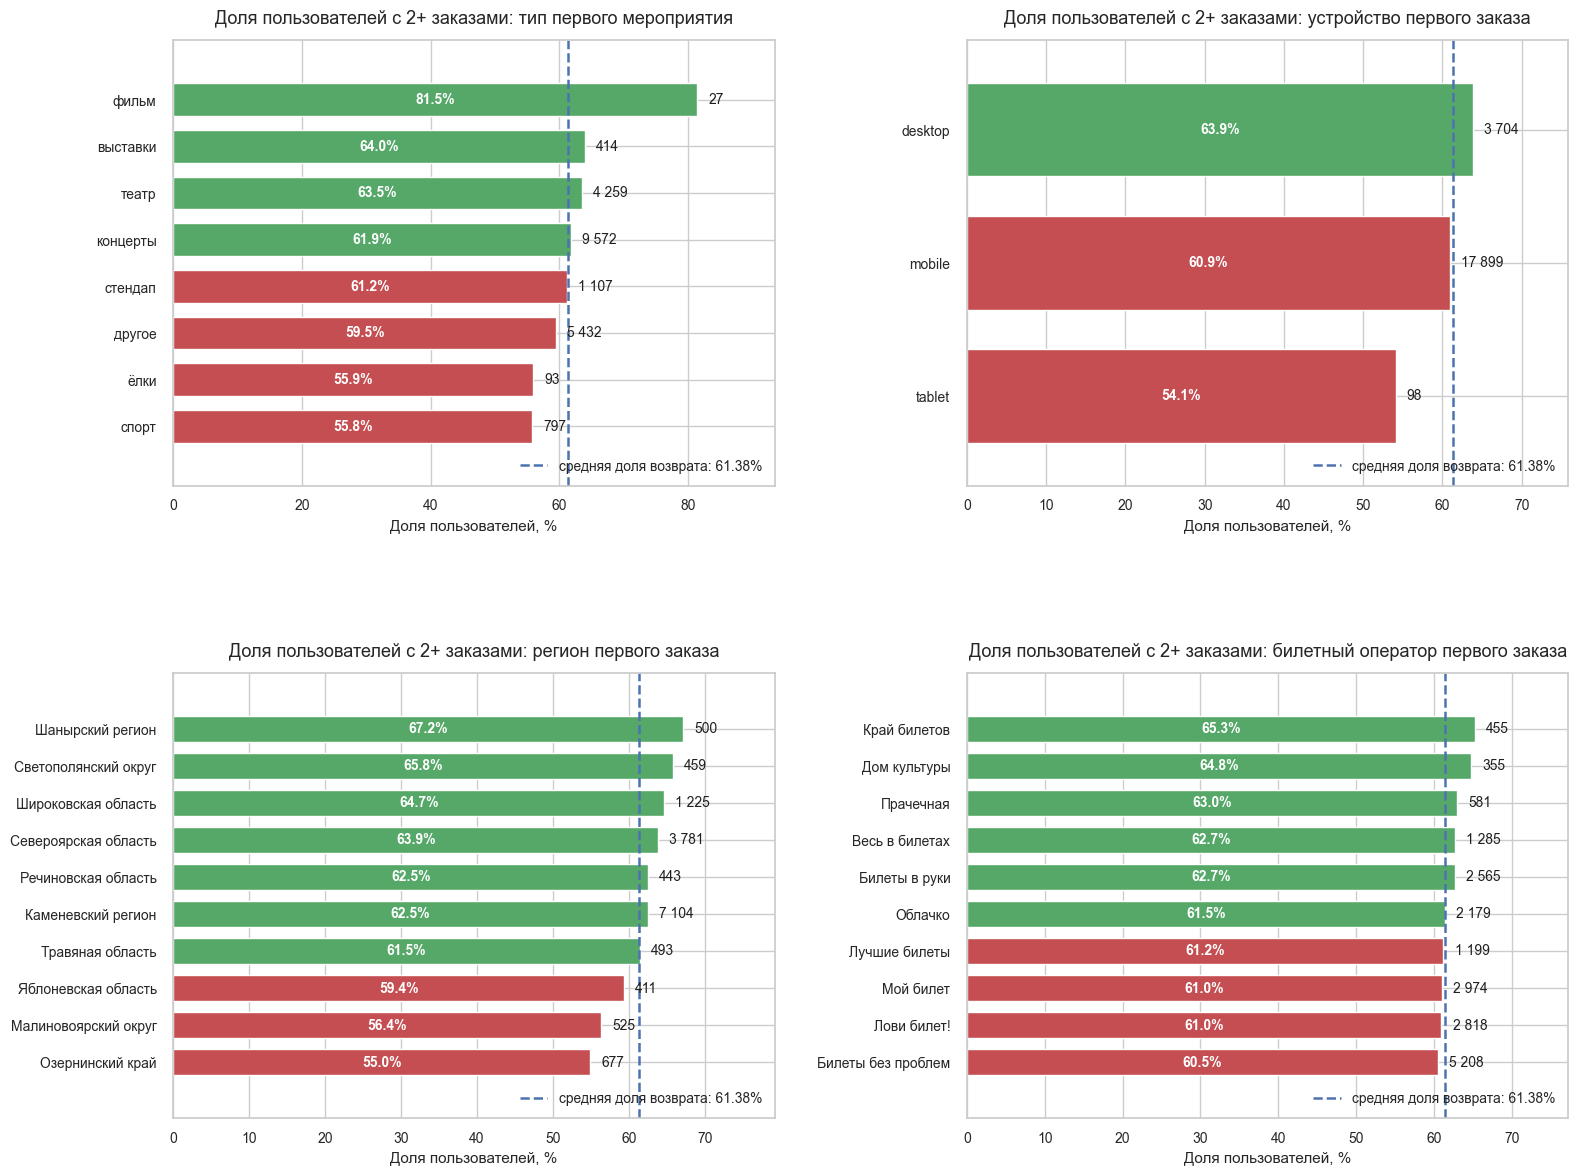

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
plot_order = [
    'first_event_type_main',
    'first_device_type',
    'first_region_name',
    'first_service_name'
]

for ax, feature in zip(axes.flat, plot_order):
    meta = segment_features[feature]
    plot_data = segment_return_tables[feature].copy()

    if feature in ['first_region_name', 'first_service_name']:
        plot_data = plot_data.head(10)

    plot_data = plot_data.sort_values('repeat_rate_pct', ascending=True)
    colors = ['#55A868' if rate > overall_repeat_rate else '#C44E52' for rate in plot_data['repeat_rate_pct']]

    bars = ax.barh(plot_data['segment'], plot_data['repeat_rate_pct'], color=colors, height=0.7)
    ax.axvline(
        overall_repeat_rate,
        color='#4C72B0',
        linestyle='--',
        linewidth=1.8,
        label=f"средняя доля возврата: {overall_repeat_rate:.2f}%"
    )

    ax.set_title(f"Доля пользователей с 2+ заказами: {meta['label']}", fontsize=13, pad=12)
    ax.set_xlabel('Доля пользователей, %', fontsize=11)
    ax.set_ylabel('')
    ax.set_xlim(0, plot_data['repeat_rate_pct'].max() + 12)
    ax.tick_params(axis='x', labelsize=10)
    ax.tick_params(axis='y', labelsize=10, pad=6)
    ax.margins(y=0.12)

    rate_labels = [f"{rate:.1f}%" for rate in plot_data['repeat_rate_pct']]
    user_labels = [f"{users:,}".replace(',', ' ') for users in plot_data['users']]

    for bar, rate_label, user_label in zip(bars, rate_labels, user_labels):
        width = bar.get_width()
        y = bar.get_y() + bar.get_height() / 2

        ax.annotate(
            rate_label,
            xy=(width / 2, y),
            ha='center',
            va='center',
            color='white',
            fontsize=10,
            fontweight='bold'
        )

        ax.annotate(
            user_label,
            xy=(width, y),
            xytext=(8, 0),
            textcoords='offset points',
            ha='left',
            va='center',
            color='#1f1f1f',
            fontsize=10
        )

    ax.legend(frameon=False, fontsize=10, loc='lower right')

plt.subplots_adjust(wspace=0.32, hspace=0.42)
plt.show()


**Промежуточный вывод (шаг 4.1.2):**

- Средняя доля пользователей с `2` и более заказами в рабочем профиле составляет `61.38%`. Это мой базовый уровень для сравнения сегментов.
- По типу первого мероприятия среди достаточно крупных сегментов лучше всего выглядят `выставки` (`64.01%`, `414` пользователей) и `театр` (`63.47%`, `4 259` пользователей). `Концерты` как самый массовый сегмент тоже чуть выше среднего (`61.89%`). `Спорт` показывает более слабый возврат (`55.83%`). Сегмент `фильм` формально лидер по доле возврата (`81.48%`), но в нём всего `27` пользователей, поэтому к нему отношусь осторожно.
- По устройству первый заказ с `desktop` связан с более высокой долей возврата (`63.88%`), чем `mobile` (`60.90%`). Но по масштабу мобильный вход всё равно остаётся главным.
- Среди крупных регионов сильнее среднего выглядят `Шанырский регион` (`67.20%`), `Светополянский округ` (`65.80%`), `Широковская область` (`64.65%`), `Североярская область` (`63.87%`) и `Каменевский регион` (`62.51%`). При этом не все массовые регионы одинаково успешны: например, `Озернинский край` (`54.95%`) и `Малиновоярский округ` (`56.38%`) заметно слабее.
- По билетным операторам среди сегментов с заметным объёмом лучше среднего выделяются `Край билетов` (`65.27%`), `Дом культуры` (`64.79%`), `Прачечная` (`62.99%`), `Весь в билетах` (`62.72%`) и `Билеты в руки` (`62.69%`). При этом самые крупные операторы не всегда дают лучший возврат: `Билеты без проблем` (`60.48%`), `Мой билет` (`61.00%`) и `Лови билет!` (`60.97%`) держатся около среднего или чуть ниже.
- **Здесь тоже учитываю охват неполных списков:** вывод по регионам относится к топ-10 сегментам, которые покрывают `71.97%` пользователей, а ещё `28.03%` остаётся вне обзора. По операторам картина устойчивее, потому что топ-10 покрывают уже `90.41%` пользователей, и за пределами таблицы остаётся только `9.59%`.
- Получается, что успешные точки входа действительно есть, но они не всегда совпадают с самыми массовыми сегментами. Поэтому дальше важно смотреть не только на долю возврата, но и на размер сегмента: маленькие категории легко дают красивый, но нестабильный результат.


---

**Задача 4.1.3.** Опираясь на выводы из задач выше, проверьте продуктовые гипотезы:

- **Гипотеза 1.** Тип мероприятия влияет на вероятность возврата на Яндекс Афишу: пользователи, которые совершили первый заказ на спортивные мероприятия, совершают повторный заказ чаще, чем пользователи, оформившие свой первый заказ на концерты.
- **Гипотеза 2.** В регионах, где больше всего пользователей посещают мероприятия, выше доля повторных заказов, чем в менее активных регионах.

---

Сначала проверяю гипотезу про тип первого мероприятия. Для этого напрямую сравниваю сегменты `спорт` и `концерты` из уже рассчитанной таблицы возвратов.

In [22]:
event_hypothesis = (
    segment_return_tables['first_event_type_main']
    .loc[lambda x: x['segment'].isin(['концерты', 'спорт']), ['segment', 'users', 'repeat_users', 'repeat_rate_pct']]
    .copy()
)
event_hypothesis['segment'] = pd.Categorical(event_hypothesis['segment'], categories=['концерты', 'спорт'], ordered=True)
event_hypothesis = event_hypothesis.sort_values('segment').reset_index(drop=True)

concerts_rate = float(event_hypothesis.loc[event_hypothesis['segment'] == 'концерты', 'repeat_rate_pct'].iloc[0])
sport_rate = float(event_hypothesis.loc[event_hypothesis['segment'] == 'спорт', 'repeat_rate_pct'].iloc[0])
event_gap = round(sport_rate - concerts_rate, 2)
event_hypothesis_supported = sport_rate > concerts_rate

print('Проверка гипотезы 1: спорт против концертов')
print(event_hypothesis.to_string(index=False))
print(f"\nРазница в доле возврата (спорт - концерты): {event_gap:.2f} п.п.")
print(f"Гипотеза 1 {'подтверждается' if event_hypothesis_supported else 'не подтверждается'}.")

Проверка гипотезы 1: спорт против концертов
 segment  users  repeat_users  repeat_rate_pct
концерты   9572          5924            61.89
   спорт    797           445            55.83

Разница в доле возврата (спорт - концерты): -6.06 п.п.
Гипотеза 1 не подтверждается.


**Результат блока:** Прямое сравнение `спорта` и `концертов` уже на таблице не подтверждает первую гипотезу: `спорт` даёт `55.83%` повторных покупок, а `концерты` — `61.89%`.


Дальше проверяю гипотезу про регионы. В качестве наиболее активных беру 3 самых массовых региона из шага `4.1.1` и сравниваю их суммарную долю возврата с остальными регионами.

In [23]:
top_active_regions = segment_distributions['first_region_name'].head(3)['segment'].tolist()

region_group_hypothesis = (
    user_profile.assign(
        region_group=np.where(
            user_profile['first_region_name'].isin(top_active_regions),
            'Топ-3 активных региона',
            'Остальные регионы'
        )
    )
    .groupby('region_group', as_index=False)
    .agg(
        users=('user_id', 'count'),
        repeat_users=('is_two', 'sum'),
        repeat_rate_pct=('is_two', lambda x: x.mean() * 100)
    )
)
region_group_hypothesis['repeat_rate_pct'] = region_group_hypothesis['repeat_rate_pct'].round(2)
region_group_hypothesis['region_group'] = pd.Categorical(
    region_group_hypothesis['region_group'],
    categories=['Топ-3 активных региона', 'Остальные регионы'],
    ordered=True
)
region_group_hypothesis = region_group_hypothesis.sort_values('region_group').reset_index(drop=True)

top_regions_rate = float(region_group_hypothesis.loc[region_group_hypothesis['region_group'] == 'Топ-3 активных региона', 'repeat_rate_pct'].iloc[0])
other_regions_rate = float(region_group_hypothesis.loc[region_group_hypothesis['region_group'] == 'Остальные регионы', 'repeat_rate_pct'].iloc[0])
region_gap = round(top_regions_rate - other_regions_rate, 2)
region_hypothesis_supported = top_regions_rate > other_regions_rate

print('Проверка гипотезы 2: самые активные регионы против остальных')
print(f"Топ-3 активных региона: {', '.join(top_active_regions)}")
print(region_group_hypothesis.to_string(index=False))
print(f"\nРазница в доле возврата: {region_gap:.2f} п.п.")
print(f"Гипотеза 2 {'подтверждается' if region_hypothesis_supported else 'не подтверждается'} для топ-3 самых массовых регионов.")

Проверка гипотезы 2: самые активные регионы против остальных
Топ-3 активных региона: Каменевский регион, Североярская область, Широковская область
          region_group  users  repeat_users  repeat_rate_pct
Топ-3 активных региона  12110          7648            63.15
     Остальные регионы   9591          5672            59.14

Разница в доле возврата: 4.01 п.п.
Гипотеза 2 подтверждается для топ-3 самых массовых регионов.


**Результат блока:** По регионам эффект получается умеренно положительным в пользу топ-3 самых массовых регионов: `63.15%` против `59.14%`. При этом группы крупные (`12 110` против `9 591` пользователей), поэтому сравнение выглядит устойчивым.


Строю итоговые графики по двум гипотезам. Внутри столбца показываю долю возврата, а у края — число пользователей, чтобы сразу видеть и эффект, и масштаб сегмента.

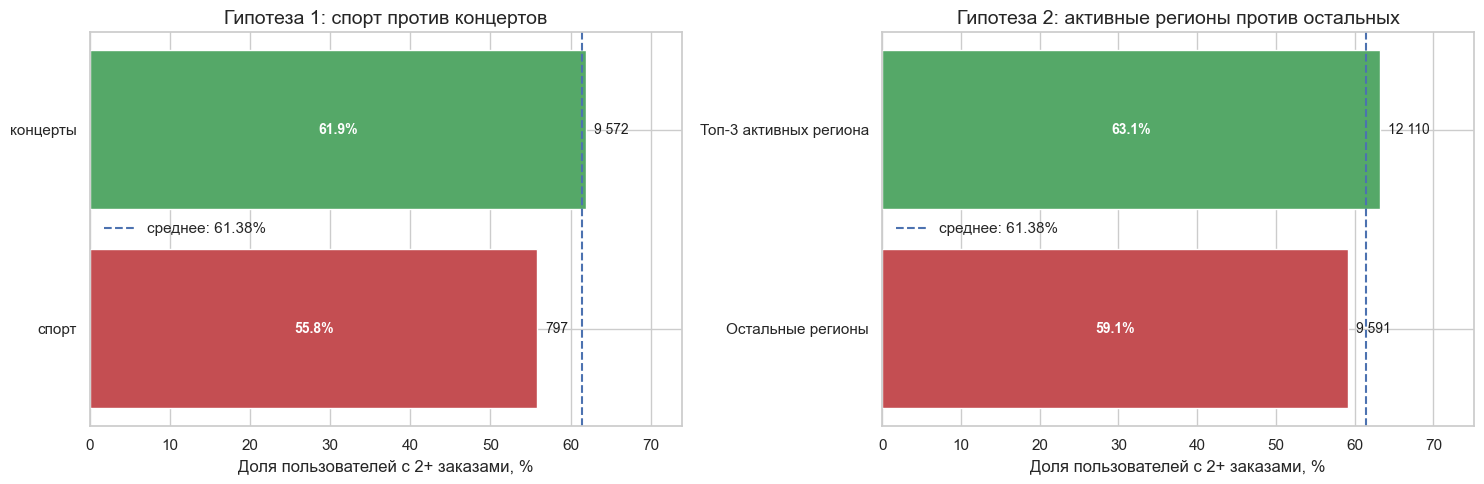

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

event_plot = event_hypothesis.sort_values('repeat_rate_pct', ascending=True)
event_colors = ['#55A868' if segment == 'концерты' else '#C44E52' for segment in event_plot['segment']]
event_bars = axes[0].barh(event_plot['segment'], event_plot['repeat_rate_pct'], color=event_colors)
axes[0].axvline(overall_repeat_rate, color='#4C72B0', linestyle='--', linewidth=1.5, label=f"среднее: {overall_repeat_rate:.2f}%")
axes[0].set_title('Гипотеза 1: спорт против концертов')
axes[0].set_xlabel('Доля пользователей с 2+ заказами, %')
axes[0].set_ylabel('')
axes[0].set_xlim(0, event_plot['repeat_rate_pct'].max() + 12)

for bar, rate, users in zip(event_bars, event_plot['repeat_rate_pct'], event_plot['users']):
    width = bar.get_width()
    y = bar.get_y() + bar.get_height() / 2
    axes[0].annotate(f"{rate:.1f}%", xy=(width / 2, y), ha='center', va='center', color='white', fontsize=10, fontweight='bold')
    axes[0].annotate(f"{users:,}".replace(',', ' '), xy=(width, y), xytext=(6, 0), textcoords='offset points', ha='left', va='center', color='#1f1f1f', fontsize=10)

axes[0].legend(frameon=False)

region_plot = region_group_hypothesis.sort_values('repeat_rate_pct', ascending=True)
region_colors = ['#55A868' if group == 'Топ-3 активных региона' else '#C44E52' for group in region_plot['region_group']]
region_bars = axes[1].barh(region_plot['region_group'], region_plot['repeat_rate_pct'], color=region_colors)
axes[1].axvline(overall_repeat_rate, color='#4C72B0', linestyle='--', linewidth=1.5, label=f"среднее: {overall_repeat_rate:.2f}%")
axes[1].set_title('Гипотеза 2: активные регионы против остальных')
axes[1].set_xlabel('Доля пользователей с 2+ заказами, %')
axes[1].set_ylabel('')
axes[1].set_xlim(0, region_plot['repeat_rate_pct'].max() + 12)

for bar, rate, users in zip(region_bars, region_plot['repeat_rate_pct'], region_plot['users']):
    width = bar.get_width()
    y = bar.get_y() + bar.get_height() / 2
    axes[1].annotate(f"{rate:.1f}%", xy=(width / 2, y), ha='center', va='center', color='white', fontsize=10, fontweight='bold')
    axes[1].annotate(f"{users:,}".replace(',', ' '), xy=(width, y), xytext=(6, 0), textcoords='offset points', ha='left', va='center', color='#1f1f1f', fontsize=10)

axes[1].legend(frameon=False)

plt.tight_layout()
plt.show()


**Промежуточный вывод (шаг 4.1.3):**

- Здесь и далее разницу в долях трактую в **процентных пунктах**. Например, `63.15%` против `59.14%` — это разница именно `4.01` процентного пункта, а не рост на `4.01%`.
- **Гипотеза 1 не подтверждается.** Пользователи, которые пришли через `спорт`, возвращаются реже, чем пользователи с первым заказом на `концерты`: `55.83%` против `61.89%`. Иначе говоря, из `100` пользователей с первым заказом на концерт повторно покупают примерно `62`, а из `100` пользователей со спортивным первым заказом — только около `56`. Разница составляет `6.06` процентного пункта в пользу концертов.
- **Гипотеза 2 в целом подтверждается**, если определить самые активные регионы как 3 крупнейших по числу пользователей из шага `4.1.1`: `Каменевский регион`, `Североярская область`, `Широковская область`.
- Важно, что эффект здесь опирается на достаточно крупные группы, а не на узкий сегмент. В топ-3 активных регионах находится `12 110` пользователей, а в остальных — `9 591`, то есть сравнение идёт между действительно сопоставимыми по масштабу частями выборки.
- В сумме по этим 3 регионам доля возврата составляет `63.15%`, тогда как по остальным регионам — `59.14%`. Это значит, что в наиболее массовых регионах повторно возвращаются примерно `63` пользователя из `100`, а в остальных — около `59` из `100`. Эффект есть, но он умеренный: разница составляет `4.01` процентного пункта.
- При этом внутри регионов сохраняется неоднородность: уже в расширенном списке крупных регионов есть и слабые сегменты. Поэтому гипотезу считаю подтверждённой на агрегированном уровне, но не как универсальное правило для каждого отдельного региона.


---

#### 4.2. Исследование поведения пользователей через показатели выручки и состава заказа

Изучите количественные характеристики заказов пользователей, чтобы узнать среднюю выручку сервиса с заказа и количество билетов, которое пользователи обычно покупают.

Эти метрики важны не только для оценки выручки, но и для оценки вовлечённости пользователей. Возможно, пользователи с более крупными и дорогими заказами более заинтересованы в сервисе и поэтому чаще возвращаются.

---

**Задача 4.2.1.** Проследите связь между средней выручкой сервиса с заказа и повторными заказами.

- Постройте сравнительные гистограммы распределения средней выручки с билета (`avg_revenue_rub`):
    - для пользователей, совершивших один заказ;
    - для вернувшихся пользователей, совершивших 2 и более заказа.
- Ответьте на вопросы:
    - В каких диапазонах средней выручки концентрируются пользователи из каждой группы?
    - Есть ли различия между группами?

Текст на сером фоне:
    
**Рекомендация:**

1. Используйте одинаковые интервалы (`bins`) и прозрачность (`alpha`), чтобы визуально сопоставить распределения.
2. Задайте параметру `density` значение `True`, чтобы сравнивать форму распределений, даже если число пользователей в группах отличается.

---


Сначала выделяю две группы пользователей внутри уже подготовленного `user_profile`: тех, кто сделал только `1` заказ, и тех, кто вернулся и сделал `2+` заказа. Затем смотрю на точные статистики и рабочие диапазоны `avg_revenue_rub`.

**Отдельно сохраняю сегмент `<=0`.** Это не обычный денежный диапазон, а небольшая группа пользователей с нулевой или отрицательной средней выручкой.


In [25]:
revenue_compare_data = user_profile[['user_id', 'total_orders', 'avg_revenue_rub', 'is_two']].copy()
revenue_compare_data['order_group'] = np.where(revenue_compare_data['is_two'] == 1, '2+ заказа', '1 заказ')

revenue_group_summary = (
    revenue_compare_data.groupby('order_group')['avg_revenue_rub']
    .agg(
        users='count',
        mean='mean',
        median='median',
        q25=lambda x: x.quantile(0.25),
        q75=lambda x: x.quantile(0.75),
        q90=lambda x: x.quantile(0.90),
        q95=lambda x: x.quantile(0.95)
    )
    .round(2)
    .reset_index()
)

revenue_range_bins = [-np.inf, 0, 250, 500, 750, 1000, 1500, np.inf]
revenue_range_labels = ['<=0', '0-250', '250-500', '500-750', '750-1000', '1000-1500', '1500+']

revenue_compare_data['revenue_range'] = pd.cut(
    revenue_compare_data['avg_revenue_rub'],
    bins=revenue_range_bins,
    labels=revenue_range_labels
)

revenue_range_distribution = (
    revenue_compare_data.groupby(['order_group', 'revenue_range'], observed=False)
    .size()
    .reset_index(name='users')
)
revenue_range_distribution['share_pct'] = (
    revenue_range_distribution.groupby('order_group')['users']
    .transform(lambda x: x / x.sum() * 100)
    .round(2)
)

revenue_range_pivot = revenue_range_distribution.pivot(
    index='revenue_range',
    columns='order_group',
    values='share_pct'
).round(2)

revenue_summary_indexed = revenue_group_summary.set_index('order_group')
revenue_range_indexed = revenue_range_pivot.fillna(0)

revenue_shift_summary = pd.Series({
    'Разница по среднему (2+ - 1), руб.': round(float(revenue_summary_indexed.loc['2+ заказа', 'mean'] - revenue_summary_indexed.loc['1 заказ', 'mean']), 2),
    'Разница по медиане (2+ - 1), руб.': round(float(revenue_summary_indexed.loc['2+ заказа', 'median'] - revenue_summary_indexed.loc['1 заказ', 'median']), 2),
    'Ширина IQR: 1 заказ, руб.': round(float(revenue_summary_indexed.loc['1 заказ', 'q75'] - revenue_summary_indexed.loc['1 заказ', 'q25']), 2),
    'Ширина IQR: 2+ заказа, руб.': round(float(revenue_summary_indexed.loc['2+ заказа', 'q75'] - revenue_summary_indexed.loc['2+ заказа', 'q25']), 2),
    'Доля <=0 у 1 заказа, %': round(float(revenue_range_indexed.loc['<=0', '1 заказ']), 2),
    'Доля <=0 у 2+ заказов, %': round(float(revenue_range_indexed.loc['<=0', '2+ заказа']), 2),
    'Доля 250-750 руб. у 1 заказа, %': round(float(revenue_range_indexed.loc['250-500', '1 заказ'] + revenue_range_indexed.loc['500-750', '1 заказ']), 2),
    'Доля 250-750 руб. у 2+ заказов, %': round(float(revenue_range_indexed.loc['250-500', '2+ заказа'] + revenue_range_indexed.loc['500-750', '2+ заказа']), 2),
    'Доля >1000 руб. у 1 заказа, %': round(float(revenue_range_indexed.loc['1000-1500', '1 заказ'] + revenue_range_indexed.loc['1500+', '1 заказ']), 2),
    'Доля >1000 руб. у 2+ заказов, %': round(float(revenue_range_indexed.loc['1000-1500', '2+ заказа'] + revenue_range_indexed.loc['1500+', '2+ заказа']), 2)
})

print('Сводные статистики по группам пользователей:')
display(revenue_group_summary)

print('Доля пользователей по диапазонам avg_revenue_rub, %:')
display(revenue_range_pivot)

print('\nКраткая сводка по сдвигу распределений:')
print(revenue_shift_summary.to_string())


Сводные статистики по группам пользователей:


,order_group,users,mean,median,q25,q75,q90,q95
0,1 заказ,8381,543.869995,376.309998,130.940002,826.320007,1290.170044,1577.800049
1,2+ заказа,13320,543.700012,494.899994,270.380005,744.349976,1023.700012,1225.550049


Доля пользователей по диапазонам avg_revenue_rub, %:


order_group,1 заказ,2+ заказа
revenue_range,,
<=0,1.37,0.34
0-250,37.30,22.72
250-500,19.85,27.55
500-750,13.01,24.80
750-1000,9.93,13.66
1000-1500,12.24,9.00
1500+,6.30,1.94



Краткая сводка по сдвигу распределений:
Разница по среднему (2+ - 1), руб.     -0.17
Разница по медиане (2+ - 1), руб.     118.59
Ширина IQR: 1 заказ, руб.             695.38
Ширина IQR: 2+ заказа, руб.           473.97
Доля <=0 у 1 заказа, %                  1.37
Доля <=0 у 2+ заказов, %                0.34
Доля 250-750 руб. у 1 заказа, %        32.86
Доля 250-750 руб. у 2+ заказов, %      52.35
Доля >1000 руб. у 1 заказа, %          18.54
Доля >1000 руб. у 2+ заказов, %        10.94


**Результат блока:** По среднему группы почти не различаются: разница между `2+` и `1` заказом составляет всего `-0.17` руб. **Зато по медиане сдвиг в пользу вернувшихся пользователей уже заметный — `+118.59` руб.**, а межквартильный диапазон у них уже (`473.97` против `695.38` руб.). Значит, у вернувшихся пользователей выручка не столько выше «в среднем», сколько **стабильнее и плотнее сосредоточена** в среднем ценовом диапазоне.


Строю сравнительные гистограммы по рекомендациям задания: использую одинаковые `bins`, прозрачность `alpha` и `density=True`, чтобы сравнивать именно форму распределений, а не абсолютный размер групп.

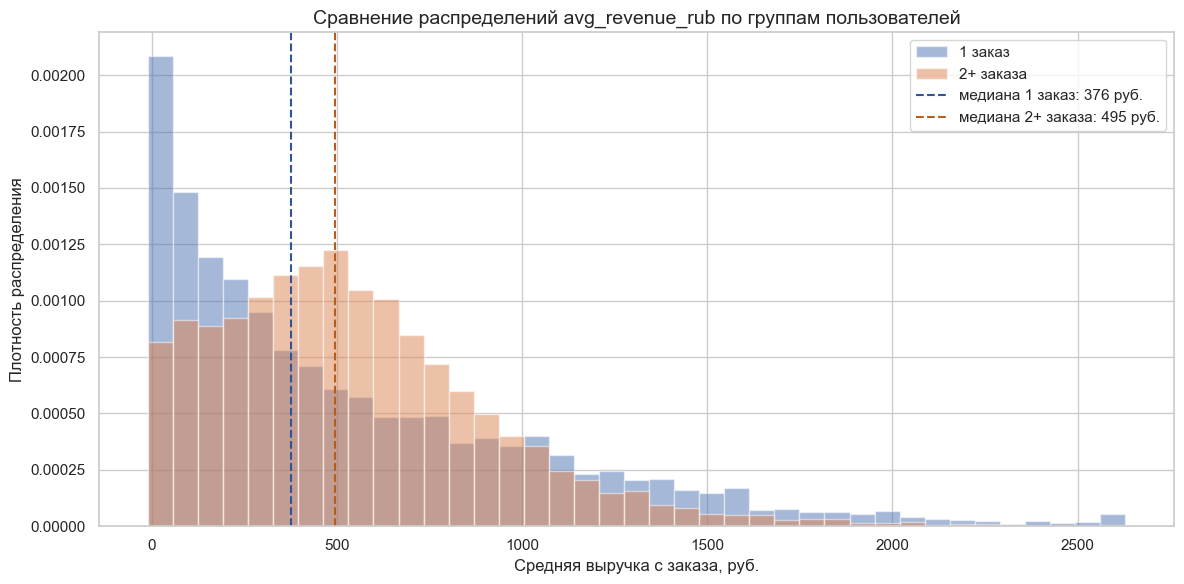

In [26]:
single_order_revenue = revenue_compare_data.loc[revenue_compare_data['order_group'] == '1 заказ', 'avg_revenue_rub']
repeat_order_revenue = revenue_compare_data.loc[revenue_compare_data['order_group'] == '2+ заказа', 'avg_revenue_rub']

hist_bins = np.linspace(revenue_compare_data['avg_revenue_rub'].min(), revenue_compare_data['avg_revenue_rub'].max(), 40)

fig, ax = plt.subplots(figsize=(12, 6))
ax.hist(single_order_revenue, bins=hist_bins, density=True, alpha=0.5, color='#4C72B0', label='1 заказ')
ax.hist(repeat_order_revenue, bins=hist_bins, density=True, alpha=0.5, color='#DD8452', label='2+ заказа')

ax.axvline(single_order_revenue.median(), color='#2F5597', linestyle='--', linewidth=1.5, label=f"медиана 1 заказ: {single_order_revenue.median():.0f} руб.")
ax.axvline(repeat_order_revenue.median(), color='#B55D1F', linestyle='--', linewidth=1.5, label=f"медиана 2+ заказа: {repeat_order_revenue.median():.0f} руб.")

ax.set_title('Сравнение распределений avg_revenue_rub по группам пользователей')
ax.set_xlabel('Средняя выручка с заказа, руб.')
ax.set_ylabel('Плотность распределения')
ax.legend()
plt.tight_layout()
plt.show()

**Промежуточный вывод (шаг 4.2.1):**

- **Если сравнивать группы в целом,** средняя `avg_revenue_rub` у них почти одинаковая: `543.87` руб. у пользователей с `1` заказом и `543.70` руб. у группы `2+` заказов. Но медиана заметно выше у вернувшихся пользователей — `494.91` руб. против `376.31` руб. Разница по медиане составляет `118.59` руб., а межквартильный диапазон у вернувшихся уже (`473.97` против `695.38` руб.). Значит, группа `2+` заказов выглядит **более стабильной и собранной вокруг среднего ценового коридора**.
- **Ключевое различие видно в диапазонах.** У пользователей с одним заказом самый крупный сегмент — `0-250` руб. (`37.30%`), а у вернувшихся пользователей основная масса уже смещена в диапазон `250-750` руб.: там находится `52.35%` наблюдений против `32.86%` у группы `1` заказа.
- **По разбросу группы тоже разные.** У пользователей с одним заказом сильнее выражены оба края распределения: и низкий сегмент, и дорогой хвост. Доля значений выше `1000` руб. у них составляет `18.54%`, тогда как у вернувшихся пользователей — `10.94%`. То есть однократные покупки выглядят более неоднородно.
- **Возможные причины такой картины** я бы сформулировал осторожно. Нулевая и отрицательная выручка у группы `1` заказа (`1.37%` против `0.34%`) может быть связана с возвратами, корректировками, бесплатными заказами по промокоду или компенсационными сценариями. Это именно рабочая гипотеза, потому что отдельного статуса возврата в выгрузке нет. А высокий дорогой хвост у однократных пользователей может отражать разовые крупные покупки, например для группы или под конкретное событие, после которых человек не формирует регулярный паттерн.
- В итоге различие между группами видно **не по среднему значению само по себе**, а по структуре распределения. Вернувшиеся пользователи чаще покупают в умеренном и более предсказуемом диапазоне, а пользователи с одним заказом ведут себя заметно более разношёрстно.


---

**Задача 4.2.2.** Сравните распределение по средней выручке с заказа в двух группах пользователей:

- совершившие 2–4 заказа;
- совершившие 5 и более заказов.

Ответьте на вопрос: есть ли различия по значению средней выручки с заказа между пользователями этих двух групп?

---


Теперь сравниваю только вернувшихся пользователей между собой: отдельно тех, кто сделал `2-4` заказа, и отдельно тех, кто дошёл до `5+` заказов. Использую тот же признак `avg_revenue_rub` и ту же логику сравнения распределений.

Как и в предыдущем шаге, сегмент `<=0` сохраняю отдельно. Его доля мала, поэтому основной вывод буду делать по положительным диапазонам выручки.

In [27]:
revenue_compare_multi = revenue_compare_data.loc[revenue_compare_data['total_orders'] >= 2].copy()
revenue_compare_multi['multi_order_group'] = np.where(
    revenue_compare_multi['total_orders'].between(2, 4),
    '2-4 заказа',
    '5+ заказов'
)

multi_revenue_summary = (
    revenue_compare_multi.groupby('multi_order_group')['avg_revenue_rub']
    .agg(
        users='count',
        mean='mean',
        median='median',
        q25=lambda x: x.quantile(0.25),
        q75=lambda x: x.quantile(0.75),
        q90=lambda x: x.quantile(0.90),
        q95=lambda x: x.quantile(0.95)
    )
    .round(2)
    .reset_index()
)

multi_revenue_range_distribution = (
    revenue_compare_multi.assign(
        revenue_range=pd.cut(
            revenue_compare_multi['avg_revenue_rub'],
            bins=revenue_range_bins,
            labels=revenue_range_labels
        )
    )
    .groupby(['multi_order_group', 'revenue_range'], observed=False)
    .size()
    .reset_index(name='users')
)
multi_revenue_range_distribution['share_pct'] = (
    multi_revenue_range_distribution.groupby('multi_order_group')['users']
    .transform(lambda x: x / x.sum() * 100)
    .round(2)
)

multi_revenue_range_pivot = multi_revenue_range_distribution.pivot(
    index='revenue_range',
    columns='multi_order_group',
    values='share_pct'
).round(2)

multi_summary_indexed = multi_revenue_summary.set_index('multi_order_group')
multi_range_indexed = multi_revenue_range_pivot.fillna(0)

multi_revenue_shift_summary = pd.Series({
    'Разница по среднему (5+ - 2-4), руб.': round(float(multi_summary_indexed.loc['5+ заказов', 'mean'] - multi_summary_indexed.loc['2-4 заказа', 'mean']), 2),
    'Разница по медиане (5+ - 2-4), руб.': round(float(multi_summary_indexed.loc['5+ заказов', 'median'] - multi_summary_indexed.loc['2-4 заказа', 'median']), 2),
    'Ширина IQR: 2-4 заказа, руб.': round(float(multi_summary_indexed.loc['2-4 заказа', 'q75'] - multi_summary_indexed.loc['2-4 заказа', 'q25']), 2),
    'Ширина IQR: 5+ заказов, руб.': round(float(multi_summary_indexed.loc['5+ заказов', 'q75'] - multi_summary_indexed.loc['5+ заказов', 'q25']), 2),
    'Доля <=0 у 2-4 заказов, %': round(float(multi_range_indexed.loc['<=0', '2-4 заказа']), 2),
    'Доля <=0 у 5+ заказов, %': round(float(multi_range_indexed.loc['<=0', '5+ заказов']), 2),
    'Доля 250-750 руб. у 2-4 заказов, %': round(float(multi_range_indexed.loc['250-500', '2-4 заказа'] + multi_range_indexed.loc['500-750', '2-4 заказа']), 2),
    'Доля 250-750 руб. у 5+ заказов, %': round(float(multi_range_indexed.loc['250-500', '5+ заказов'] + multi_range_indexed.loc['500-750', '5+ заказов']), 2),
    'Доля >1000 руб. у 2-4 заказов, %': round(float(multi_range_indexed.loc['1000-1500', '2-4 заказа'] + multi_range_indexed.loc['1500+', '2-4 заказа']), 2),
    'Доля >1000 руб. у 5+ заказов, %': round(float(multi_range_indexed.loc['1000-1500', '5+ заказов'] + multi_range_indexed.loc['1500+', '5+ заказов']), 2)
})

print('Сводные статистики по группам 2-4 и 5+ заказов:')
display(multi_revenue_summary)

print('Доля пользователей по диапазонам avg_revenue_rub, %:')
display(multi_revenue_range_pivot)

print('\nКраткая сводка по сдвигу распределений:')
print(multi_revenue_shift_summary.to_string())


Сводные статистики по группам 2-4 и 5+ заказов:


,multi_order_group,users,mean,median,q25,q75,q90,q95
0,2-4 заказа,7181,550.929993,470.399994,218.220001,798.479980,1114.979980,1339.290039
1,5+ заказов,6139,535.229980,512.090027,330.160004,700.280029,921.039978,1061.079956


Доля пользователей по диапазонам avg_revenue_rub, %:


multi_order_group,2-4 заказа,5+ заказов
revenue_range,,
<=0,0.47,0.18
0-250,27.77,16.81
250-500,24.50,31.11
500-750,19.06,31.50
750-1000,13.77,13.52
1000-1500,11.43,6.16
1500+,2.99,0.72



Краткая сводка по сдвигу распределений:
Разница по среднему (5+ - 2-4), руб.    -15.70
Разница по медиане (5+ - 2-4), руб.      41.69
Ширина IQR: 2-4 заказа, руб.            580.26
Ширина IQR: 5+ заказов, руб.            370.12
Доля <=0 у 2-4 заказов, %                 0.47
Доля <=0 у 5+ заказов, %                  0.18
Доля 250-750 руб. у 2-4 заказов, %       43.56
Доля 250-750 руб. у 5+ заказов, %        62.61
Доля >1000 руб. у 2-4 заказов, %         14.42
Доля >1000 руб. у 5+ заказов, %           6.88


**Результат блока:** И здесь среднее само по себе не даёт полного ответа: у группы `5+` заказов оно даже чуть ниже на `15.70` руб. **Зато медиана выше на `41.69` руб.**, а межквартильный диапазон заметно уже (`370.12` против `580.26` руб.). Значит, у более лояльных пользователей траты выглядят **ровнее и стабильнее**, даже если среднее не растёт. В прикладном смысле это похоже на более сформированный сценарий досуга: такие пользователи не просто тратят больше в отдельные моменты, а **регулярнее покупают в понятном для себя ценовом диапазоне**.


Строю сравнительные гистограммы с одинаковыми `bins`, `alpha` и `density=True`, чтобы сопоставить именно форму распределений у двух групп вернувшихся пользователей.

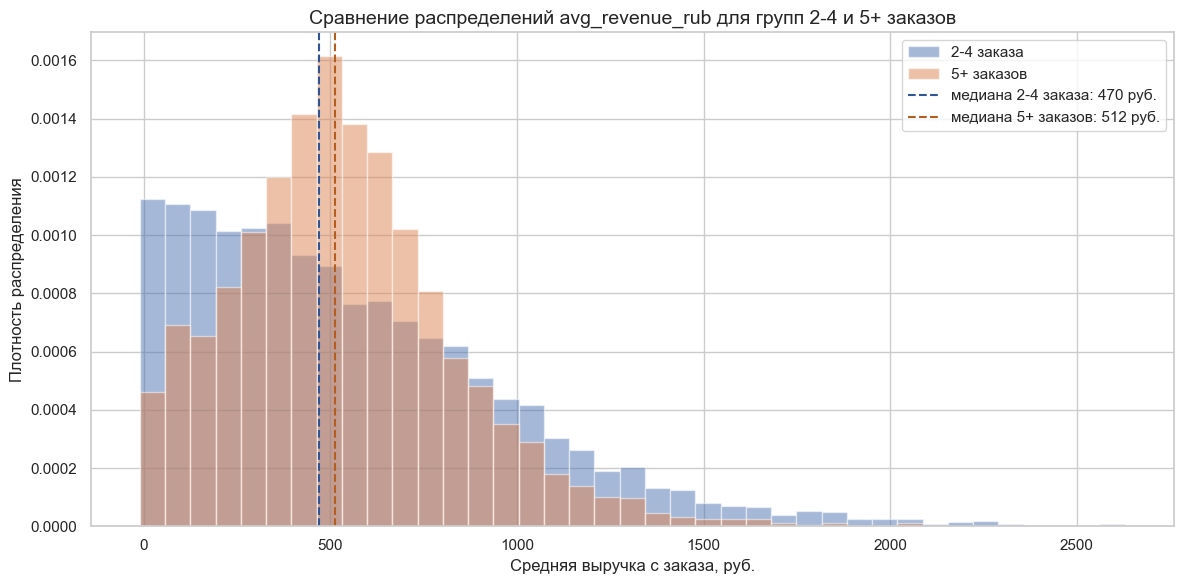

In [28]:
revenue_2_4 = revenue_compare_multi.loc[revenue_compare_multi['multi_order_group'] == '2-4 заказа', 'avg_revenue_rub']
revenue_5_plus = revenue_compare_multi.loc[revenue_compare_multi['multi_order_group'] == '5+ заказов', 'avg_revenue_rub']

fig, ax = plt.subplots(figsize=(12, 6))
ax.hist(revenue_2_4, bins=hist_bins, density=True, alpha=0.5, color='#4C72B0', label='2-4 заказа')
ax.hist(revenue_5_plus, bins=hist_bins, density=True, alpha=0.5, color='#DD8452', label='5+ заказов')

ax.axvline(revenue_2_4.median(), color='#2F5597', linestyle='--', linewidth=1.5, label=f"медиана 2-4 заказа: {revenue_2_4.median():.0f} руб.")
ax.axvline(revenue_5_plus.median(), color='#B55D1F', linestyle='--', linewidth=1.5, label=f"медиана 5+ заказов: {revenue_5_plus.median():.0f} руб.")

ax.set_title('Сравнение распределений avg_revenue_rub для групп 2-4 и 5+ заказов')
ax.set_xlabel('Средняя выручка с заказа, руб.')
ax.set_ylabel('Плотность распределения')
ax.legend()
plt.tight_layout()
plt.show()

**Промежуточный вывод (шаг 4.2.2):**

- **Если сравнивать группы в целом,** пользователи с `5+` заказами выглядят стабильнее. Их средняя `avg_revenue_rub` немного ниже (`535.23` руб. против `550.93` руб. у группы `2-4 заказа`), но медиана выше — `512.09` руб. против `470.40` руб. При этом межквартильный диапазон у группы `5+` заметно уже (`370.12` против `580.26` руб.), то есть распределение менее разболтано.
- **Ключевое различие снова видно в диапазонах.** У пользователей с `5+` заказами основной центр тяжести находится в интервале `250-750` руб.: это `62.61%` наблюдений. У группы `2-4 заказа` в этих же диапазонах только `43.56%`, зато у неё сильнее представлены и низкие значения `0-250` руб. (`27.77%`), и дорогой хвост.
- **По верхнему хвосту группа `2-4 заказа` тоже выглядит заметно более разнородной.** Значения выше `1000` руб. у неё встречаются в `14.42%` случаев, тогда как у группы `5+` заказов — только в `6.88%`.
- **Сегмент `<=0` в обеих группах очень мал** (`0.47%` и `0.18%`), поэтому на общий вывод он почти не влияет.
- Возможное объяснение здесь такое: пользователи с `5+` заказами, похоже, уже нашли для себя привычный и комфортный уровень трат и покупают в нём более регулярно. А группа `2-4 заказа` выглядит более смешанной: в ней одновременно есть и осторожные покупки в нижнем диапазоне, и отдельные дорогие заказы, которые могут быть разовыми.
- **Итоговое суждение о характере выборок** я бы сформулировал так: группа `5+` заказов выглядит более зрелой и устойчивой по поведению, а группа `2-4 заказа` — более переходной и неоднородной. Похоже, что пользователи, которые действительно регулярно организуют свой досуг через сервис, не обязательно тратят больше в среднем, но **намного чаще держатся в стабильном среднем диапазоне и возвращаются к нему снова**.


---

**Задача 4.2.3.** Проанализируйте влияние среднего количества билетов в заказе на вероятность повторной покупки.

- Изучите распределение пользователей по среднему количеству билетов в заказе (`avg_tickets_count`) и опишите основные наблюдения.
- Разделите пользователей на несколько сегментов по среднему количеству билетов в заказе:
    - от 1 до 2 билетов;
    - от 2 до 3 билетов;
    - от 3 до 5 билетов;
    - от 5 и более билетов.
- Для каждого сегмента подсчитайте общее число пользователей и долю пользователей, совершивших повторные заказы.
- Ответьте на вопросы:
    - Как распределены пользователи по сегментам — равномерно или сконцентрировано?
    - Есть ли сегменты с аномально высокой или низкой долей повторных покупок?

---

Сначала оцениваю общий профиль по признаку `avg_tickets_count` и **сразу формирую сегменты**, которые дальше использую в таблицах и на графиках.


In [29]:
avg_ticket_stats = (
    user_profile['avg_tickets_count']
    .describe(percentiles=[0.25, 0.5, 0.75, 0.95, 0.99])
    .rename({
        'count': 'users',
        'mean': 'mean',
        '50%': 'median',
        '75%': 'q75',
        '95%': 'q95',
        '99%': 'q99',
        'max': 'max'
    })
    .loc[['users', 'mean', 'median', 'q75', 'q95', 'q99', 'max']]
    .round(2)
    .to_frame(name='value')
)

ticket_segment_bins = [1, 2, 3, 5, np.inf]
ticket_segment_labels = ['1-2 билета', '2-3 билета', '3-5 билетов', '5+ билетов']

ticket_segment_data = user_profile[['user_id', 'avg_tickets_count', 'is_two']].copy()
ticket_segment_data['tickets_segment'] = pd.cut(
    ticket_segment_data['avg_tickets_count'],
    bins=ticket_segment_bins,
    labels=ticket_segment_labels,
    right=False,
    include_lowest=True
)

ticket_segment_summary = (
    ticket_segment_data
    .groupby('tickets_segment', observed=False)
    .agg(
        users=('user_id', 'count'),
        repeat_users=('is_two', 'sum'),
        repeat_rate=('is_two', 'mean')
    )
    .reset_index()
)

ticket_segment_summary['share_pct'] = (
    ticket_segment_summary['users'] / ticket_segment_summary['users'].sum() * 100
).round(2)
ticket_segment_summary['repeat_rate_pct'] = (
    ticket_segment_summary['repeat_rate'] * 100
).round(2)
ticket_segment_summary['repeat_users'] = ticket_segment_summary['repeat_users'].astype('int32')
ticket_segment_summary['above_avg'] = np.where(
    ticket_segment_summary['repeat_rate_pct'] > overall_repeat_rate,
    'выше среднего',
    'не выше среднего'
)

print('Сводные статистики по avg_tickets_count:')
display(avg_ticket_stats)

print('Сегменты по среднему количеству билетов:')
display(ticket_segment_summary[['tickets_segment', 'users', 'share_pct', 'repeat_users', 'repeat_rate_pct', 'above_avg']])

Сводные статистики по avg_tickets_count:


,value
users,21701.00
mean,2.74
median,2.75
q75,3.09
q95,4.00
q99,5.00
max,11.00


Сегменты по среднему количеству билетов:


,tickets_segment,users,share_pct,repeat_users,repeat_rate_pct,above_avg
0,1-2 билета,2431,11.20,1248,51.34,не выше среднего
1,2-3 билета,9520,43.87,7011,73.64,выше среднего
2,3-5 билетов,9089,41.88,4936,54.31,не выше среднего
3,5+ билетов,661,3.05,125,18.91,не выше среднего


**Результат блока:** Основная масса пользователей попадает в сегменты `2-3` и `3-5` билетов, вместе это `85.75%` рабочего профиля. Сам признак выглядит компактным: медиана равна `2.75`, а `99`-й перцентиль — `5`.


Дальше показываю форму распределения и отдельно смотрю, насколько пользователи сконцентрированы в заданных сегментах.

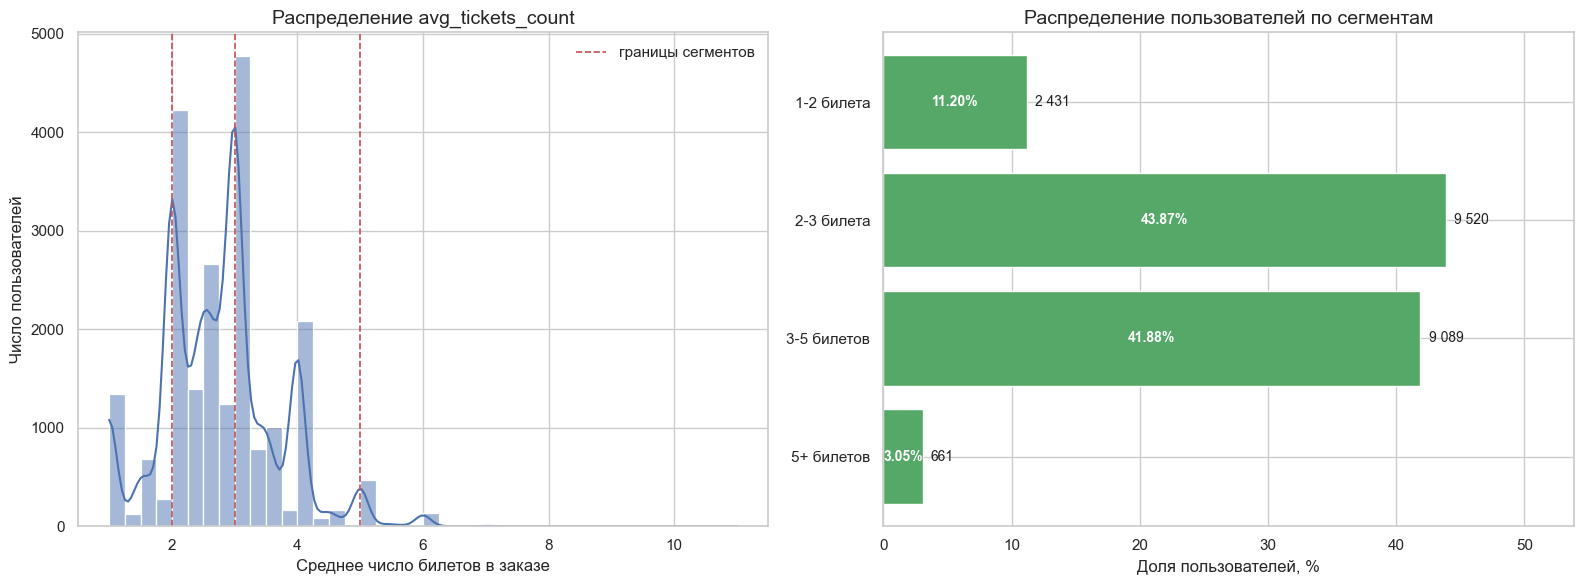

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

hist_bins = np.arange(1, user_profile['avg_tickets_count'].max() + 0.25, 0.25)
sns.histplot(user_profile['avg_tickets_count'], bins=hist_bins, kde=True, ax=axes[0], color='#4C72B0')

for boundary, label in zip([2, 3, 5], ['границы сегментов', '_nolegend_', '_nolegend_']):
    axes[0].axvline(boundary, color='#C44E52', linestyle='--', linewidth=1.2, label=label)

axes[0].set_title('Распределение avg_tickets_count')
axes[0].set_xlabel('Среднее число билетов в заказе')
axes[0].set_ylabel('Число пользователей')
axes[0].legend(frameon=False)

segment_share_plot = ticket_segment_summary.copy()
bars = axes[1].barh(segment_share_plot['tickets_segment'].astype(str), segment_share_plot['share_pct'], color='#55A868')
axes[1].invert_yaxis()
axes[1].set_title('Распределение пользователей по сегментам')
axes[1].set_xlabel('Доля пользователей, %')
axes[1].set_ylabel('')
axes[1].set_xlim(0, segment_share_plot['share_pct'].max() + 10)

share_labels = [f"{share:.2f}%" for share in segment_share_plot['share_pct']]
user_labels = [f"{users:,}".replace(',', ' ') for users in segment_share_plot['users']]

for bar, share_label, user_label in zip(bars, share_labels, user_labels):
    width = bar.get_width()
    y = bar.get_y() + bar.get_height() / 2

    axes[1].annotate(
        share_label,
        xy=(width / 2, y),
        ha='center',
        va='center',
        color='white',
        fontsize=10,
        fontweight='bold'
    )

    axes[1].annotate(
        user_label,
        xy=(width, y),
        xytext=(6, 0),
        textcoords='offset points',
        ha='left',
        va='center',
        color='#1f1f1f',
        fontsize=10
    )

plt.tight_layout()
plt.show()


Теперь сравниваю долю пользователей с `2+` заказами между сегментами и соотношу её со средним уровнем возврата по всему `user_profile`.

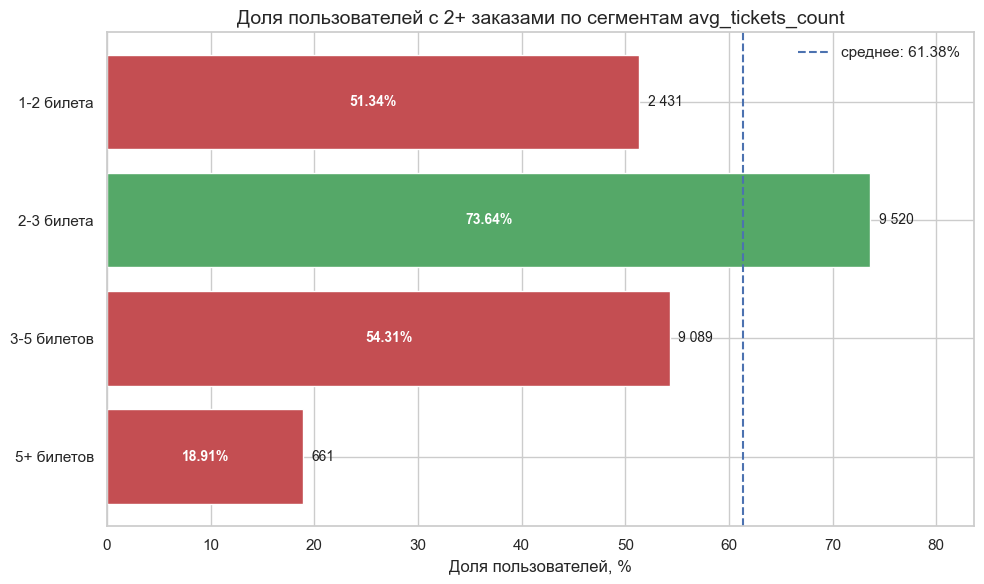

In [31]:
fig, ax = plt.subplots(figsize=(10, 6))

repeat_plot = ticket_segment_summary.copy()
colors = ['#55A868' if rate > overall_repeat_rate else '#C44E52' for rate in repeat_plot['repeat_rate_pct']]

bars = ax.barh(repeat_plot['tickets_segment'].astype(str), repeat_plot['repeat_rate_pct'], color=colors)
ax.invert_yaxis()
ax.axvline(
    overall_repeat_rate,
    color='#4C72B0',
    linestyle='--',
    linewidth=1.5,
    label=f"среднее: {overall_repeat_rate:.2f}%"
)

ax.set_title('Доля пользователей с 2+ заказами по сегментам avg_tickets_count')
ax.set_xlabel('Доля пользователей, %')
ax.set_ylabel('')
ax.set_xlim(0, repeat_plot['repeat_rate_pct'].max() + 10)

rate_labels = [f"{rate:.2f}%" for rate in repeat_plot['repeat_rate_pct']]
user_labels = [f"{users:,}".replace(',', ' ') for users in repeat_plot['users']]

for bar, rate_label, user_label in zip(bars, rate_labels, user_labels):
    width = bar.get_width()
    y = bar.get_y() + bar.get_height() / 2

    ax.annotate(
        rate_label,
        xy=(width / 2, y),
        ha='center',
        va='center',
        color='white',
        fontsize=10,
        fontweight='bold'
    )

    ax.annotate(
        user_label,
        xy=(width, y),
        xytext=(6, 0),
        textcoords='offset points',
        ha='left',
        va='center',
        color='#1f1f1f',
        fontsize=10
    )

ax.legend(frameon=False)

plt.tight_layout()
plt.show()


**Промежуточный вывод (шаг 4.2.3):**

- Здесь картина получилась особенно интересной: признак `avg_tickets_count` сконцентрирован вокруг `2-3` билетов. Среднее значение равно `2.74`, медиана — `2.75`, `95`-й перцентиль — `4`, `99`-й — `5`. Значит, для большинства пользователей типичный заказ небольшой или средний по размеру.
- Распределение по сегментам неравномерное. Основная масса пользователей сосредоточена в группах `2-3 билета` (`9 520` пользователей, `43.87%`) и `3-5 билетов` (`9 089`, `41.88%`). Вместе это `85.75%` всего рабочего профиля. Сегмент `5+ билетов` редкий: `661` пользователь, `3.05%`.
- Самая высокая доля повторных заказов у сегмента `2-3 билета` — `73.64%`, что заметно выше среднего уровня по выборке (`61.38%`). Это самый сильный сегмент по удержанию внутри данного признака.
- Сегменты `1-2 билета` (`51.34%`) и `3-5 билетов` (`54.31%`) уже ниже среднего, а `5+ билетов` показывает особенно низкий возврат — `18.91%`. Этот результат считаю значимым, потому что в сегменте всё же `661` пользователь, то есть наблюдений достаточно для осторожной интерпретации.
- **В сегментном анализе эта зависимость не выглядит монотонной:** лучший возврат связан не с максимально крупными заказами, а с умеренным средним объёмом около `2-3` билетов. Это видно по самой таблице и графику по сегментам: после роста до `73.64%` в группе `2-3 билета` доля повторных покупок дальше снижается до `54.31%` в сегменте `3-5 билетов` и до `18.91%` в сегменте `5+ билетов`. Похоже, что здесь чаще встречаются небольшие совместные походы на мероприятия: такие сценарии выглядят более регулярными и жизненными, чем крупные разовые покупки.
- Очень крупные средние заказы `5+` билетов, наоборот, больше похожи на групповые или организационные сценарии. После таких покупок пользователи возвращаются заметно реже, поэтому сам размер заказа здесь, скорее всего, отражает разный тип поведения, а не просто силу интереса к платформе.


---

#### 4.3. Исследование временных характеристик первого заказа и их влияния на повторные покупки

Изучите временные параметры, связанные с первым заказом пользователей:

- день недели первой покупки;
- время с момента первой покупки — лайфтайм;
- средний интервал между покупками пользователей с повторными заказами.

---

**Задача 4.3.1.** Проанализируйте, как день недели, в которой была совершена первая покупка, влияет на поведение пользователей.

- По данным даты первого заказа выделите день недели.
- Для каждого дня недели подсчитайте общее число пользователей и долю пользователей, совершивших повторные заказы. Результаты визуализируйте.
- Ответьте на вопрос: влияет ли день недели, в которую совершена первая покупка, на вероятность возврата клиента?

---


Сначала выделяю день недели первого заказа внутри уже готового `user_profile` и собираю сводную таблицу по числу пользователей и доле возврата.

In [32]:
weekday_names = ['Понедельник', 'Вторник', 'Среда', 'Четверг', 'Пятница', 'Суббота', 'Воскресенье']

user_profile['first_order_weekday_num'] = user_profile['first_order_dt'].dt.weekday.astype('int8')
user_profile['first_order_weekday'] = pd.Categorical.from_codes(
    user_profile['first_order_weekday_num'],
    categories=weekday_names,
    ordered=True
)

weekday_summary = (
    user_profile
    .groupby('first_order_weekday', observed=False)
    .agg(
        users=('user_id', 'count'),
        repeat_users=('is_two', 'sum'),
        repeat_rate=('is_two', 'mean')
    )
    .reset_index()
)

weekday_summary['share_pct'] = (
    weekday_summary['users'] / weekday_summary['users'].sum() * 100
).round(2)
weekday_summary['repeat_rate_pct'] = (
    weekday_summary['repeat_rate'] * 100
).round(2)
weekday_summary['repeat_users'] = weekday_summary['repeat_users'].astype('int32')
weekday_summary['gap_from_avg_pp'] = (
    weekday_summary['repeat_rate_pct'] - overall_repeat_rate
).round(2)
weekday_summary['above_avg'] = np.where(
    weekday_summary['repeat_rate_pct'] > overall_repeat_rate,
    'выше среднего',
    'не выше среднего'
)

weekday_best = weekday_summary.loc[weekday_summary['repeat_rate_pct'].idxmax()].copy()
weekday_worst = weekday_summary.loc[weekday_summary['repeat_rate_pct'].idxmin()].copy()
weekday_repeat_spread_pp = round(
    float(weekday_best['repeat_rate_pct'] - weekday_worst['repeat_rate_pct']),
    2
)

print('Распределение пользователей по дню недели первого заказа:')
display(
    weekday_summary[
        ['first_order_weekday', 'users', 'share_pct', 'repeat_users', 'repeat_rate_pct', 'gap_from_avg_pp', 'above_avg']
    ]
)

Распределение пользователей по дню недели первого заказа:


,first_order_weekday,users,share_pct,repeat_users,repeat_rate_pct,gap_from_avg_pp,above_avg
0,Понедельник,2940,13.55,1854,63.06,1.68,выше среднего
1,Вторник,3186,14.68,1976,62.02,0.64,выше среднего
2,Среда,3070,14.15,1912,62.28,0.90,выше среднего
3,Четверг,3117,14.36,1852,59.42,-1.96,не выше среднего
4,Пятница,3261,15.03,1956,59.98,-1.40,не выше среднего
5,Суббота,3335,15.37,2098,62.91,1.53,выше среднего
6,Воскресенье,2792,12.87,1672,59.89,-1.49,не выше среднего


**Результат блока:** Пользователи по дням первой покупки распределены довольно ровно, без резких перекосов. Уже по сводной таблице видно, что разброс по возврату между днями недели небольшой.


Дальше отдельно показываю, как пользователи распределены по дням первой покупки, и сравниваю долю возврата со средним уровнем по всей выборке.

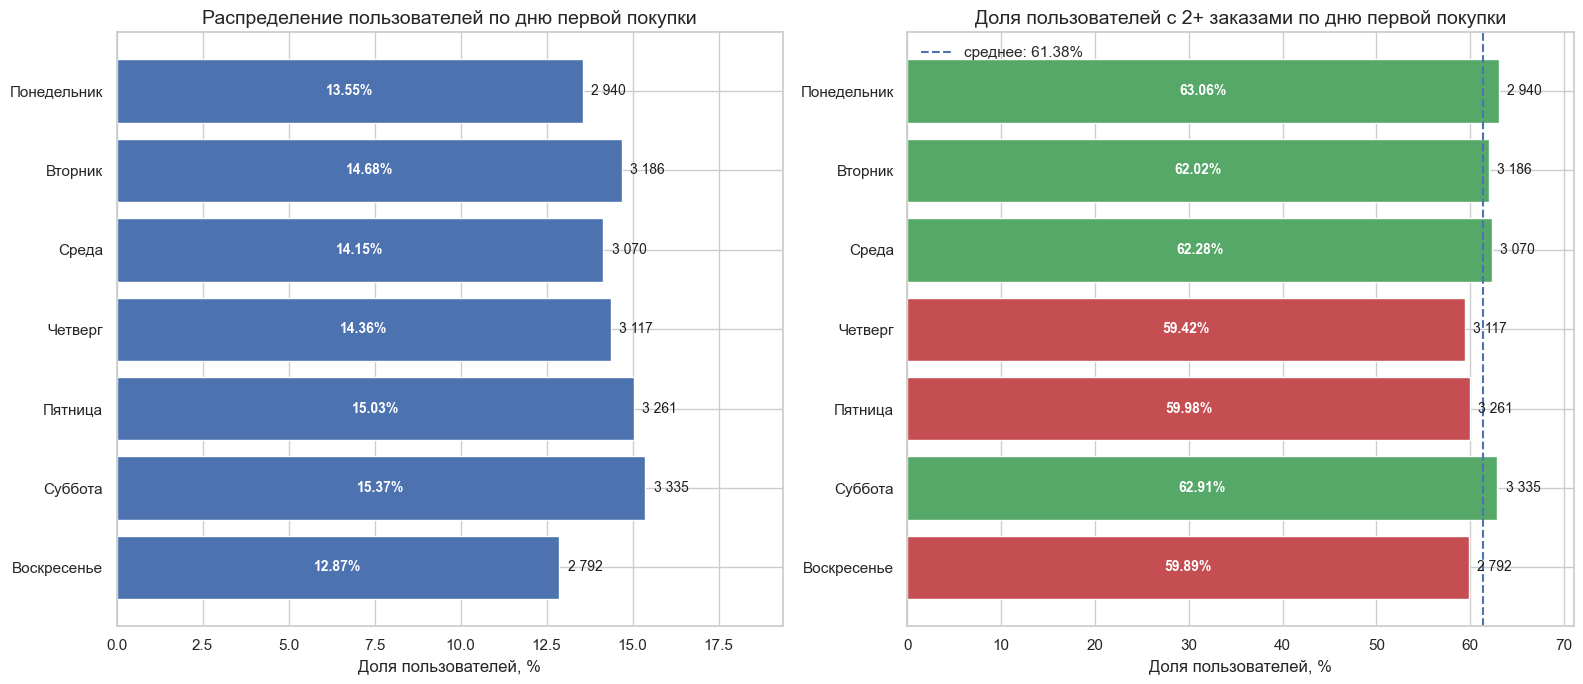

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

weekday_plot = weekday_summary.copy()

bars_left = axes[0].barh(
    weekday_plot['first_order_weekday'].astype(str),
    weekday_plot['share_pct'],
    color='#4C72B0'
)
axes[0].invert_yaxis()
axes[0].set_title('Распределение пользователей по дню первой покупки')
axes[0].set_xlabel('Доля пользователей, %')
axes[0].set_ylabel('')
axes[0].set_xlim(0, weekday_plot['share_pct'].max() + 4)

share_labels = [f"{share:.2f}%" for share in weekday_plot['share_pct']]
user_labels = [f"{users:,}".replace(',', ' ') for users in weekday_plot['users']]

for bar, share_label, user_label in zip(bars_left, share_labels, user_labels):
    width = bar.get_width()
    y = bar.get_y() + bar.get_height() / 2

    axes[0].annotate(
        share_label,
        xy=(width / 2, y),
        ha='center',
        va='center',
        color='white',
        fontsize=10,
        fontweight='bold'
    )

    axes[0].annotate(
        user_label,
        xy=(width, y),
        xytext=(6, 0),
        textcoords='offset points',
        ha='left',
        va='center',
        color='#1f1f1f',
        fontsize=10
    )

colors = ['#55A868' if rate > overall_repeat_rate else '#C44E52' for rate in weekday_plot['repeat_rate_pct']]
bars_right = axes[1].barh(
    weekday_plot['first_order_weekday'].astype(str),
    weekday_plot['repeat_rate_pct'],
    color=colors
)
axes[1].invert_yaxis()
axes[1].axvline(
    overall_repeat_rate,
    color='#4C72B0',
    linestyle='--',
    linewidth=1.5,
    label=f"среднее: {overall_repeat_rate:.2f}%"
)
axes[1].set_title('Доля пользователей с 2+ заказами по дню первой покупки')
axes[1].set_xlabel('Доля пользователей, %')
axes[1].set_ylabel('')
axes[1].set_xlim(0, weekday_plot['repeat_rate_pct'].max() + 8)

rate_labels = [f"{rate:.2f}%" for rate in weekday_plot['repeat_rate_pct']]

for bar, rate_label, user_label in zip(bars_right, rate_labels, user_labels):
    width = bar.get_width()
    y = bar.get_y() + bar.get_height() / 2

    axes[1].annotate(
        rate_label,
        xy=(width / 2, y),
        ha='center',
        va='center',
        color='white',
        fontsize=10,
        fontweight='bold'
    )

    axes[1].annotate(
        user_label,
        xy=(width, y),
        xytext=(6, 0),
        textcoords='offset points',
        ha='left',
        va='center',
        color='#1f1f1f',
        fontsize=10
    )

axes[1].legend(frameon=False)

plt.tight_layout()
plt.show()


**Промежуточный вывод (шаг 4.3.1):**

- Сильного перекоса по дням первой покупки нет: доля каждого дня лежит в диапазоне от `12.87%` до `15.37%`. Самые объёмные дни — `суббота` (`3 335` пользователей, `15.37%`) и `пятница` (`3 261`, `15.03%`), а наименьшая доля у `воскресенья` (`2 792`, `12.87%`).
- По доле повторных заказов лучший результат показывает `понедельник` — `63.06%`. Близко к нему `суббота` (`62.91%`), `среда` (`62.28%`) и `вторник` (`62.02%`).
- Ниже среднего уровня по выборке (`61.38%`) находятся `четверг` (`59.42%`), `воскресенье` (`59.89%`) и `пятница` (`59.98%`). Самый слабый день — `четверг`.
- При этом разброс между лучшим и худшим днём составляет только `3.64` процентного пункта. То есть влияние дня недели есть, но оно скорее фоновое, чем решающее.
- Для практики я бы не использовал день недели как самостоятельный сильный фактор удержания. Скорее это хороший дополнительный признак, который имеет смысл смотреть вместе с типом первого события, устройством и параметрами заказа.


---

**Задача 4.3.2.** Изучите, как средний интервал между заказами влияет на удержание клиентов.

- Рассчитайте среднее время между заказами для двух групп пользователей:
    - совершившие 2–4 заказа;
    - совершившие 5 и более заказов.
- Исследуйте, как средний интервал между заказами влияет на вероятность повторного заказа, и сделайте выводы.

---


Признак `avg_days_between_orders` есть только у пользователей с повторными заказами. Поэтому здесь я оцениваю не сам факт первого возврата, а глубину удержания: чем отличаются интервалы у групп `2-4` и `5+` заказов.

In [34]:
interval_compare_data = (
    revenue_compare_multi[['user_id', 'multi_order_group']]
    .merge(
        user_profile[['user_id', 'avg_days_between_orders']],
        on='user_id',
        how='left'
    )
)

interval_compare_stats = (
    interval_compare_data.groupby('multi_order_group')['avg_days_between_orders']
    .agg(
        users='count',
        mean='mean',
        median='median',
        q25=lambda x: x.quantile(0.25),
        q75=lambda x: x.quantile(0.75),
        q90=lambda x: x.quantile(0.90),
        q95=lambda x: x.quantile(0.95)
    )
    .reset_index()
    .round(2)
)

interval_range_bins = [0, 1, 3, 7, 14, 30, np.inf]
interval_range_labels = ['<1 дня', '1-3 дня', '3-7 дней', '7-14 дней', '14-30 дней', '30+ дней']

interval_compare_data['interval_range'] = pd.cut(
    interval_compare_data['avg_days_between_orders'],
    bins=interval_range_bins,
    labels=interval_range_labels,
    right=False,
    include_lowest=True
)

interval_range_distribution = (
    interval_compare_data
    .groupby(['multi_order_group', 'interval_range'], observed=False)
    .size()
    .reset_index(name='users')
)
interval_range_distribution['share_pct'] = (
    interval_range_distribution['users']
    / interval_range_distribution.groupby('multi_order_group')['users'].transform('sum')
    * 100
).round(2)

interval_range_pivot = interval_range_distribution.pivot(
    index='interval_range',
    columns='multi_order_group',
    values='share_pct'
).fillna(0)

interval_best = interval_compare_stats.loc[interval_compare_stats['mean'].idxmin()].copy()
interval_worst = interval_compare_stats.loc[interval_compare_stats['mean'].idxmax()].copy()
interval_mean_gap = round(float(interval_worst['mean'] - interval_best['mean']), 2)

print('Сводные статистики по avg_days_between_orders:')
display(interval_compare_stats)

print('Доля пользователей по диапазонам avg_days_between_orders, %:')
display(interval_range_pivot)

Сводные статистики по avg_days_between_orders:


,multi_order_group,users,mean,median,q25,q75,q90,q95
0,2-4 заказа,7181,21.40,9.00,0.00,34.00,60.00,85.000000
1,5+ заказов,6139,9.98,8.22,3.92,14.25,21.34,26.200001


Доля пользователей по диапазонам avg_days_between_orders, %:


multi_order_group,2-4 заказа,5+ заказов
interval_range,,
<1 дня,35.89,7.20
1-3 дня,4.97,11.92
3-7 дней,5.75,24.27
7-14 дней,8.44,30.69
14-30 дней,16.17,23.59
30+ дней,28.78,2.33


**Результат блока:** У группы `5+` заказов средний интервал между покупками получается короче и стабильнее, чем у группы `2-4` заказа. Это уже на таблице подсказывает, что глубокое удержание связано скорее с регулярностью, чем с разовыми всплесками активности.


На гистограмме ограничиваю ось X `90` днями, чтобы длинный хвост группы `2-4` заказов не сжимал основную часть распределения. Все значения при этом сохранены в расчётах и таблицах.

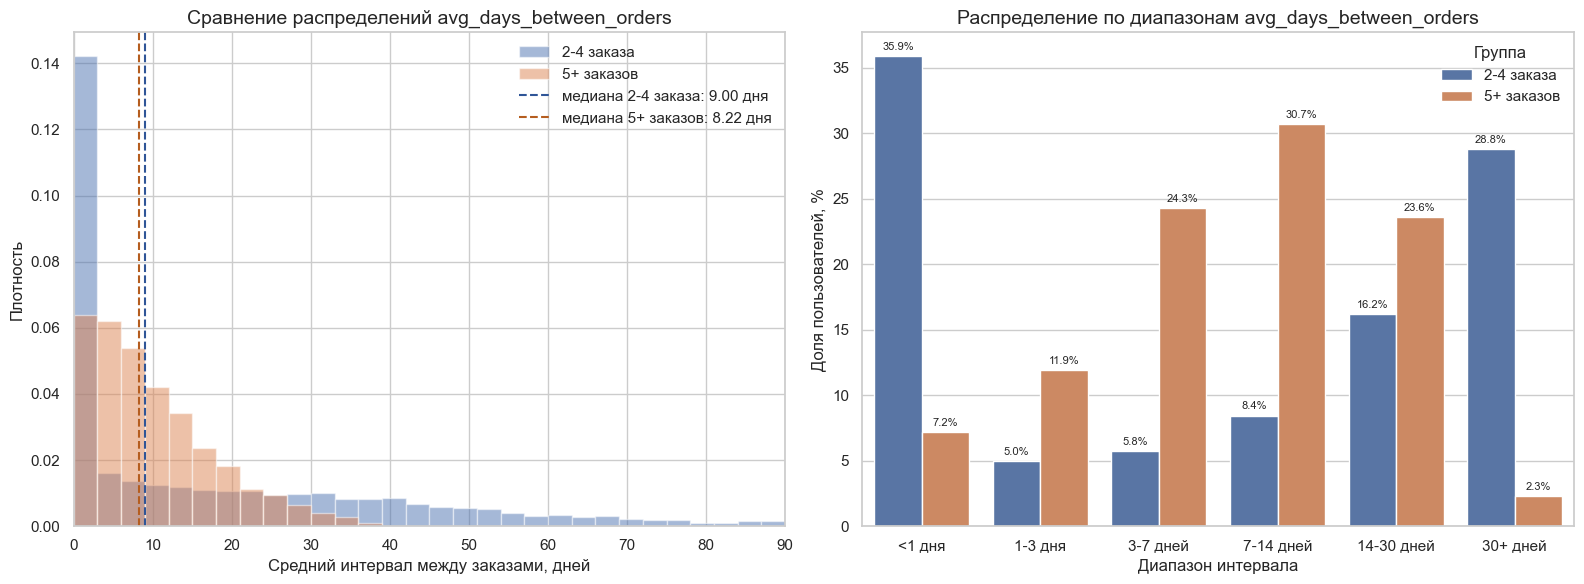

In [35]:
interval_2_4 = interval_compare_data.loc[
    interval_compare_data['multi_order_group'] == '2-4 заказа',
    'avg_days_between_orders'
]
interval_5_plus = interval_compare_data.loc[
    interval_compare_data['multi_order_group'] == '5+ заказов',
    'avg_days_between_orders'
]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

hist_bins = np.linspace(0, 90, 31)
axes[0].hist(interval_2_4, bins=hist_bins, density=True, alpha=0.5, color='#4C72B0', label='2-4 заказа')
axes[0].hist(interval_5_plus, bins=hist_bins, density=True, alpha=0.5, color='#DD8452', label='5+ заказов')
axes[0].axvline(interval_2_4.median(), color='#2F5597', linestyle='--', linewidth=1.5, label=f"медиана 2-4 заказа: {interval_2_4.median():.2f} дня")
axes[0].axvline(interval_5_plus.median(), color='#B55D1F', linestyle='--', linewidth=1.5, label=f"медиана 5+ заказов: {interval_5_plus.median():.2f} дня")
axes[0].set_title('Сравнение распределений avg_days_between_orders')
axes[0].set_xlabel('Средний интервал между заказами, дней')
axes[0].set_ylabel('Плотность')
axes[0].set_xlim(0, 90)
axes[0].legend(frameon=False)

range_plot = interval_range_distribution.copy()
sns.barplot(
    data=range_plot,
    x='interval_range',
    y='share_pct',
    hue='multi_order_group',
    palette=['#4C72B0', '#DD8452'],
    ax=axes[1]
)
axes[1].set_title('Распределение по диапазонам avg_days_between_orders')
axes[1].set_xlabel('Диапазон интервала')
axes[1].set_ylabel('Доля пользователей, %')
axes[1].legend(title='Группа', frameon=False)

for container in axes[1].containers:
    for bar in container:
        height = bar.get_height()
        if height > 0:
            axes[1].annotate(
                f"{height:.1f}%",
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),
                textcoords='offset points',
                ha='center',
                va='bottom',
                fontsize=8
            )

plt.tight_layout()
plt.show()


**Промежуточный вывод (шаг 4.3.2):**

- Главное наблюдение здесь такое: у пользователей с `5+` заказами интервал между покупками не просто короче, а заметно стабильнее. По среднему значению он равен `9.98` дня против `21.40` дня у группы `2-4 заказа`, хотя медианы различаются намного слабее — `8.22` и `9.00` дня.
- Группа `5+` заказов выглядит более ровной по ритму покупок. `90.47%` пользователей здесь укладываются в диапазон от `1` до `30` дней, а самые плотные сегменты — `7-14 дней` (`30.69%`) и `3-7 дней` (`24.27%`).
- У группы `2-4 заказа` распределение заметно более неоднородное. С одной стороны, `35.89%` пользователей имеют средний интервал меньше `1` дня. С другой стороны, ещё `28.78%` попадают в диапазон `30+` дней. Это похоже на смесь двух сценариев: либо несколько заказов совершаются почти в один день, либо между покупками возникают длинные паузы.
- Поэтому сам по себе очень короткий средний интервал ещё не гарантирует более сильное удержание. Для группы `2-4` он часто может отражать не устойчивый цикл покупок, а дробление заказов в рамках одной даты или очень короткой серии действий.
- В целом более глубокое удержание связано не просто с минимальным интервалом, а с более регулярным и умеренно коротким ритмом покупок. Пользователи, которые доходят до `5+` заказов, чаще возвращаются в течение `1-30` дней и делают это заметно ровнее.


---

#### 4.4. Корреляционный анализ количества покупок и признаков пользователя

Изучите, какие характеристики первого заказа и профиля пользователя могут быть связаны с числом покупок. Для этого используйте универсальный коэффициент корреляции `phi_k`, который позволяет анализировать как числовые, так и категориальные признаки.

---

**Задача 4.4.1:** Проведите корреляционный анализ:
- Рассчитайте коэффициент корреляции `phi_k` между признаками профиля пользователя и числом заказов (`total_orders`). При необходимости используйте параметр `interval_cols` для определения интервальных данных.
- Проанализируйте полученные результаты. Если полученные значения будут близки к нулю, проверьте разброс данных в `total_orders`. Такое возможно, когда в данных преобладает одно значение: в таком случае корреляционный анализ может показать отсутствие связей. Чтобы этого избежать, выделите сегменты пользователей по полю `total_orders`, а затем повторите корреляционный анализ. Выделите такие сегменты:
    - 1 заказ;
    - от 2 до 4 заказов;
    - от 5 и выше.
- Визуализируйте результат корреляции с помощью тепловой карты.
- Ответьте на вопрос: какие признаки наиболее связаны с количеством заказов?

---

Сначала я считаю прямую корреляцию `phi_k` между признаками профиля пользователя и `total_orders`.

- Для числовых признаков я **явно задаю параметр `interval_cols`**.
- `is_two` и `is_five` в матрицу не включаю, потому что они напрямую построены из `total_orders`.


In [36]:
feature_name_map = {
    'first_order_day_num': 'дата первого заказа',
    'last_order_day_num': 'дата последнего заказа',
    'first_event_type_main': 'тип первого мероприятия',
    'first_device_type': 'устройство первого заказа',
    'first_region_name': 'регион первого заказа',
    'first_service_name': 'оператор первого заказа',
    'avg_revenue_rub': 'средняя выручка с заказа',
    'avg_tickets_count': 'среднее число билетов',
    'avg_days_between_orders': 'средний интервал между заказами',
    'total_orders': 'число заказов',
    'order_count_group': 'сегмент по числу заказов'
}

profile_start_dt = user_profile['first_order_dt'].min()
user_profile['first_order_day_num'] = (
    user_profile['first_order_dt'] - profile_start_dt
).dt.days.astype('int16')
user_profile['last_order_day_num'] = (
    user_profile['last_order_dt'] - profile_start_dt
).dt.days.astype('int16')

corr_feature_cols = [
    'total_orders',
    'first_order_day_num',
    'last_order_day_num',
    'first_event_type_main',
    'first_device_type',
    'first_region_name',
    'first_service_name',
    'avg_revenue_rub',
    'avg_tickets_count',
    'avg_days_between_orders'
]

phik_total_orders = user_profile[corr_feature_cols].phik_matrix(
    interval_cols=[
        'total_orders',
        'first_order_day_num',
        'last_order_day_num',
        'avg_revenue_rub',
        'avg_tickets_count',
        'avg_days_between_orders'
    ]
)

corr_total_orders_summary = (
    phik_total_orders['total_orders']
    .drop('total_orders')
    .sort_values(ascending=False)
    .rename_axis('feature')
    .reset_index(name='phi_k')
)
corr_total_orders_summary['Признак'] = corr_total_orders_summary['feature'].map(feature_name_map)
corr_total_orders_summary = corr_total_orders_summary[['feature', 'Признак', 'phi_k']]

print('Корреляция phi_k признаков профиля с total_orders:')
corr_total_orders_summary[['Признак', 'phi_k']].round(3)
        


Корреляция phi_k признаков профиля с total_orders:


,Признак,phi_k
0,дата первого заказа,0.424
1,дата последнего заказа,0.356
2,средний интервал между заказами,0.286
3,среднее число билетов,0.225
4,средняя выручка с заказа,0.220
5,регион первого заказа,0.121
6,тип первого мероприятия,0.051
7,оператор первого заказа,0.022
8,устройство первого заказа,0.014


**Результат блока:** Уже на первом расчёте `phi_k` значения не близки к нулю. Самые заметные связи с `total_orders` дают временные признаки и параметры корзины, поэтому дополнительную сегментацию дальше использую как усиление, а не как замену основного результата.


Дальше я отдельно проверяю распределение `total_orders`, потому что это прямо требуется в задании.

Повторный расчёт на сегментах `1 заказ`, `2-4 заказа` и `5+ заказов` я **использую как усиление анализа**.


In [37]:
order_count_distribution = (
    user_profile['total_orders']
    .value_counts()
    .sort_index()
    .rename_axis('total_orders')
    .reset_index(name='users')
)
order_count_distribution['share_pct'] = (
    order_count_distribution['users'] / len(user_profile) * 100
).round(2)

user_profile['order_count_group'] = pd.Categorical(
    pd.cut(
        user_profile['total_orders'],
        bins=[0, 1, 4, np.inf],
        labels=['1 заказ', '2-4 заказа', '5+ заказов'],
        right=True
    ),
    categories=['1 заказ', '2-4 заказа', '5+ заказов'],
    ordered=True
)

order_count_group_distribution = (
    user_profile['order_count_group']
    .value_counts(sort=False)
    .rename_axis('order_count_group')
    .reset_index(name='users')
)
order_count_group_distribution['share_pct'] = (
    order_count_group_distribution['users'] / len(user_profile) * 100
).round(2)

corr_group_cols = [
    'order_count_group',
    'first_order_day_num',
    'last_order_day_num',
    'first_event_type_main',
    'first_device_type',
    'first_region_name',
    'first_service_name',
    'avg_revenue_rub',
    'avg_tickets_count',
    'avg_days_between_orders'
]

phik_order_groups = user_profile[corr_group_cols].phik_matrix(
    interval_cols=[
        'first_order_day_num',
        'last_order_day_num',
        'avg_revenue_rub',
        'avg_tickets_count',
        'avg_days_between_orders'
    ]
)

corr_order_group_summary = (
    phik_order_groups['order_count_group']
    .drop('order_count_group')
    .sort_values(ascending=False)
    .rename_axis('feature')
    .reset_index(name='phi_k')
)
corr_order_group_summary['Признак'] = corr_order_group_summary['feature'].map(feature_name_map)
corr_order_group_summary = corr_order_group_summary[['feature', 'Признак', 'phi_k']]

print('Распределение пользователей по total_orders (первые 15 значений):')
display(order_count_distribution.head(15))

print('Распределение пользователей по сегментам числа заказов:')
display(order_count_group_distribution)

print('Корреляция phi_k признаков профиля с сегментом по числу заказов:')
corr_order_group_summary[['Признак', 'phi_k']].round(3)
            


Распределение пользователей по total_orders (первые 15 значений):


,total_orders,users,share_pct
0,1,8381,38.62
1,2,3585,16.52
2,3,2192,10.10
3,4,1404,6.47
4,5,976,4.50
5,6,701,3.23
6,7,540,2.49
7,8,457,2.11
8,9,385,1.77
9,10,292,1.35


Распределение пользователей по сегментам числа заказов:


,order_count_group,users,share_pct
0,1 заказ,8381,38.62
1,2-4 заказа,7181,33.09
2,5+ заказов,6139,28.29


Корреляция phi_k признаков профиля с сегментом по числу заказов:


,Признак,phi_k
0,дата последнего заказа,0.487
1,дата первого заказа,0.473
2,средний интервал между заказами,0.388
3,среднее число билетов,0.384
4,средняя выручка с заказа,0.327
5,регион первого заказа,0.124
6,оператор первого заказа,0.089
7,тип первого мероприятия,0.053
8,устройство первого заказа,0.028


**Результат блока:** Распределение `total_orders` остаётся скошенным вправо: `38.62%` пользователей имеют только `1` заказ. После перехода к сегментам `1`, `2-4` и `5+` можно проверить, сохранится ли та же картина связей в более устойчивом виде.


Для итоговой интерпретации вывожу две тепловые карты: отдельно для прямой связи с `total_orders` и отдельно для связи с сегментированным таргетом. **Для `phi_k` использую одноцветную шкалу `Reds`, потому что коэффициент лежит в диапазоне от `0` до `1` и не бывает отрицательным.**


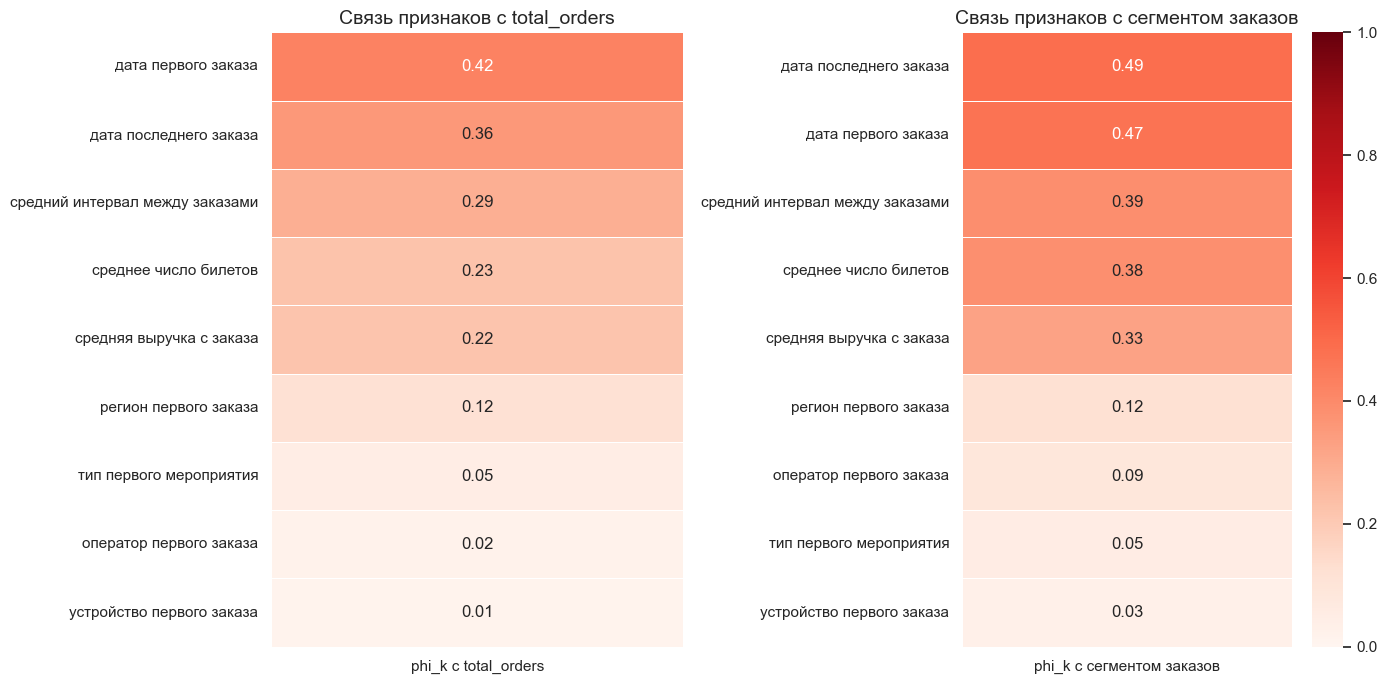

In [38]:
heatmap_total = (
    corr_total_orders_summary[['Признак', 'phi_k']]
    .set_index('Признак')
    .rename(columns={'phi_k': 'phi_k с total_orders'})
)

heatmap_group = (
    corr_order_group_summary[['Признак', 'phi_k']]
    .set_index('Признак')
    .rename(columns={'phi_k': 'phi_k с сегментом заказов'})
)

fig, axes = plt.subplots(1, 2, figsize=(14, 7))

sns.heatmap(
    heatmap_total,
    annot=True,
    fmt='.2f',
    cmap='Reds',
    vmin=0,
    vmax=1,
    linewidths=0.5,
    cbar=False,
    ax=axes[0]
)
axes[0].set_title('Связь признаков с total_orders')
axes[0].set_xlabel('')
axes[0].set_ylabel('')

sns.heatmap(
    heatmap_group,
    annot=True,
    fmt='.2f',
    cmap='Reds',
    vmin=0,
    vmax=1,
    linewidths=0.5,
    cbar=True,
    ax=axes[1]
)
axes[1].set_title('Связь признаков с сегментом заказов')
axes[1].set_xlabel('')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()


**Результат блока:** На тепловых картах картина читается стабильно: сильнее всего с количеством заказов связаны временные признаки, `avg_days_between_orders`, `avg_tickets_count` и `avg_revenue_rub`. Это хорошо совпадает с выводами предыдущих шагов.


**Промежуточный вывод (шаг 4.4.1):**

- Формальное условие из задания про «значения, близкие к нулю» в моём случае не сработало. Уже на первом расчёте `phi_k` я получил заметные связи с `total_orders`, поэтому базовый вывод делаю именно по прямой матрице корреляций.
- В прямом расчёте сильнее всего с числом заказов связаны `дата первого заказа` (`0.424`) и `дата последнего заказа` (`0.356`). Это выглядит вполне логично: пользователи, которые пришли раньше и оставались активными позже, успели накопить больше заказов внутри наблюдаемого периода.
- Среди остальных признаков заметнее всего выделяются `avg_days_between_orders` (`0.286`), `avg_tickets_count` (`0.225`) и `avg_revenue_rub` (`0.220`). То есть число заказов сильнее связано с ритмом покупок, наполнением заказа и общей интенсивностью поведения, чем с характеристиками самой первой точки входа.
- Среди категориальных признаков первого заказа самым заметным остаётся только `регион первого заказа` (`0.121`). Связь `типа первого мероприятия` (`0.051`), `оператора первого заказа` (`0.022`) и `устройства первого заказа` (`0.014`) слабая.
- Затем я дополнительно проверил разброс `total_orders`: распределение остаётся скошенным вправо, потому что `38.62%` пользователей имеют `1` заказ, `33.09%` попадают в группу `2-4 заказа`, ещё `28.29%` — в группу `5+` заказов.
- Повторный расчёт на сегментах не заменяет первый анализ, а просто делает вывод устойчивее и нагляднее. После сегментации картина сохранилась и стала ещё понятнее: наиболее сильные сигналы дают `дата последнего заказа` (`0.487`), `дата первого заказа` (`0.473`), `avg_days_between_orders` (`0.388`), `avg_tickets_count` (`0.384`) и `avg_revenue_rub` (`0.327`).
- `is_two` и `is_five` я сознательно не включал в матрицу, потому что они напрямую определяются через `total_orders`. Их корреляция с таргетом была бы ожидаемо высокой, но аналитически мало что добавила бы.
- В итоге здесь особенно хорошо видно главное: повторные покупки сильнее всего объясняются временным поведением пользователя и параметрами его корзины. Демография первого контакта, устройство и даже первый сервис играют уже вторичную роль.


### 5. Общий вывод и рекомендации

В конце проекта напишите общий вывод и рекомендации: расскажите заказчику, на что нужно обратить внимание. В выводах кратко укажите:

- **Информацию о данных**, с которыми вы работали, и то, как они были подготовлены: например, расскажите о фильтрации данных, переводе тенге в рубли, фильтрации выбросов.
- **Основные результаты анализа.** Например, укажите:
    - Сколько пользователей в выборке? Как распределены пользователи по числу заказов? Какие ещё статистические показатели вы подсчитали важным во время изучения данных?
    - Какие признаки первого заказа связаны с возвратом пользователей?
    - Как связаны средняя выручка и количество билетов в заказе с вероятностью повторных покупок?
    - Какие временные характеристики влияют на удержание (день недели, интервалы между покупками)?
    - Какие характеристики первого заказа и профиля пользователя могут быть связаны с числом покупок согласно результатам корреляционного анализа?
- Дополните выводы информацией, которая покажется вам важной и интересной. Следите за общим объёмом выводов — они должны быть компактными и ёмкими.

В конце предложите заказчику рекомендации о том, как именно действовать в его ситуации. Например, укажите, на какие сегменты пользователей стоит обратить внимание в первую очередь, а какие нуждаются в дополнительных маркетинговых усилиях.

Если посмотреть на проект целиком, то сначала коротко зафиксирую, с какими данными я работал и как подготовил их к анализу.

- На входе у меня было `292 034` заказа и `14` признаков.
- На этапе предобработки я перевёл выручку в рубли, привёл типы данных, проверил пропуски, категории и дубликаты. **Полных дублей и повторов по `order_id` не нашёл**. Широкая проверка неполных дублей на уровне дня дала `53 158` кандидатов, но при ужесточении через точный `order_ts` их осталось только `44`, поэтому такие совпадения я **не трактовал как реальное массовое задвоение** и не удалял автоматически.
- **Заказы с `revenue_rub <= 0` (`6 153` строк, или `2.11%` данных) я сознательно не исключал автоматически.** По смыслу они больше похожи на возвраты, корректировки, компенсационные или бесплатные сценарии, чем на обычную выручку. Но в исходной выгрузке нет отдельного признака возврата или отмены, поэтому такие наблюдения сохранил как технический сегмент и дальше интерпретировал осторожно.
- После фильтрации верхнего хвоста по `revenue_rub` выше `99`-го перцентиля я удалил `2 840` строк, то есть только `0.97%` заказов. После этого в рабочем датафрейме осталось `289 194` заказа.
- Затем я построил профиль пользователя и отдельно отфильтровал `219` сверхактивных профилей с `total_orders` выше `99`-го перцентиля. Это `1.00%` профиля, после фильтрации в рабочем наборе осталось `21 701` пользователь.
- **Итоговые потери считаю некритичными**: на уровне заказов и на уровне пользовательского профиля данных осталось достаточно для дальнейшего анализа и устойчивых выводов.


**Общий вывод по результатам анализа:**

- **С точки зрения качества данных подготовка прошла без критичных потерь.** После очистки и фильтраций я сохранил `289 194` заказа и `21 701` рабочий профиль пользователя. Явных дублей в данных не увидел, а проверка неполных дублей показала важную деталь: широкая дневная эвристика сильно переоценивает проблему, потому что после ужесточения по точному времени заказа остаётся только `44` случая. Небольшой сегмент заказов с нулевой или отрицательной выручкой тоже сохранил как технический: по смыслу он ближе к возвратам, корректировкам или бесплатным сценариям, чем к обычным продажам, но без отдельного статуса операции автоматически исключать его было бы слишком рискованно.
- Если собрать результаты вместе, картина получается довольно цельной: `38.62%` пользователей сделали только `1` заказ, `33.09%` попали в группу `2-4 заказа`, ещё `28.29%` — в группу `5+` заказов. Общая доля пользователей с `2+` заказами составила `61.38%`.
- Среди признаков первого заказа различия по возврату есть, но они скорее умеренные, чем радикальные. Лучше среднего выглядят `театр` (`63.47%`), `desktop` (`63.88%`) и ряд регионов, а гипотеза про преимущество `спорта` не подтвердилась: `55.83%` против `61.89%` у `концертов`.
- Средняя выручка сама по себе разделяет группы не очень сильно, но типичный уровень выручки у вернувшихся пользователей выше. Для пользователей с `2+` заказами медиана `avg_revenue_rub` составляет `494.91` руб. против `376.31` руб. у группы с одним заказом.
- Один из самых сильных и при этом понятных сигналов я увидел в размере заказа по билетам. У сегмента `2-3 билета` доля повторных покупок максимальна и достигает `73.64%`. Для `1-2` билетов она снижается до `51.34%`, а для `5+` билетов — до `18.91%`.
- День недели первой покупки влияет на возврат умеренно: разброс между лучшим и худшим днём составил только `3.64` процентного пункта. Намного важнее здесь выглядит ритм покупок: у пользователей с `5+` заказами `90.47%` средних интервалов укладываются в диапазон `1-30` дней.
- Корреляционный анализ `phi_k` показал, что число заказов сильнее всего связано с датами первого и последнего заказа, а также с `avg_days_between_orders`, `avg_tickets_count` и `avg_revenue_rub`. Иначе говоря, глубина покупательского поведения заметно важнее, чем характеристики самой первой точки входа.


**Рекомендации для заказчика:**

1. Я бы в первую очередь опирался не на устройство или жанр первого события, а на поведенческие признаки пользователя: частоту покупок, средний интервал между заказами, среднее число билетов и среднюю выручку. Именно они сильнее связаны с числом заказов.
2. Для retention-кампаний в первую очередь стоит тестировать пользователей с профилем `2-3 билета` и с регулярным ритмом покупок в диапазоне примерно `3-14` дней. По этим сегментам сигнал на возврат выглядит самым сильным и при этом достаточно устойчивым.
3. Пользователей с длинными паузами (`30+` дней), с низким средним чеком и с профилем `1-2 билета` я бы относил к зоне риска и отдельно усиливал промо, напоминания и более простые сценарии возврата.
4. Региональные различия учитывать полезно, но скорее как дополнительный слой сегментации. Массовые и сильные регионы действительно показывают лучший возврат, однако сам по себе регион объясняет поведение слабее, чем количественные признаки профиля.
5. Если дальше строить модель прогнозирования возврата, я бы закладывал в основу признаки типа `recency / frequency / monetary`, интервалы между заказами и характеристики корзины. При этом `is_two` и `is_five` нельзя использовать как обычные признаки для такой модели, если целевая переменная связана с количеством заказов, потому что это уже производные от таргета.


### 6. Финализация проекта и публикация в Git

Когда вы закончите анализировать данные, оформите проект, а затем опубликуйте его.

Выполните следующие действия:

1. Создайте файл `.gitignore`. Добавьте в него все временные и чувствительные файлы, которые не должны попасть в репозиторий.
2. Сформируйте файл `requirements.txt`. Зафиксируйте все библиотеки, которые вы использовали в проекте.
3. Вынести все чувствительные данные (параметры подключения к базе) в `.env`файл.
4. Проверьте, что проект запускается и воспроизводим.
5. Загрузите проект в публичный репозиторий — например, на GitHub. Убедитесь, что все нужные файлы находятся в репозитории, исключая те, что в `.gitignore`. Ссылка на репозиторий понадобится для отправки проекта на проверку. Вставьте её в шаблон проекта в тетрадке Jupyter Notebook перед отправкой проекта на ревью.

**Ссылка на публичный репозиторий проекта:**

https://github.com/neiro/TaskModule2
